In [1]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [2]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [3]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog

In [4]:
#Import data
from load_data import load_data

indep_vars, dep_vars = load_data('../AirFogSim/output/global_data.csv')

In [ ]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 3 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
"""

In [5]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehicle counts.
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot
Note: Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacity per node (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions. It shows complex oscillating behavior over time. Please consider:
- Polynomial terms (e.g., x1², x2³)
- Logarithmic or exponential structures
- Residual combinations or moving average style components

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs. It must be in the range [0, 1]. You are encouraged to use structures that naturally output bounded values, such as:
- Sigmoid: y = 1 / (1 + exp(-(…)))
- Bounded min/max: y = min(1, max(0, …))
"""

Running experiment 1...


d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:26: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  self.llm = ChatOpenAI(temperature=temp, model=model)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:36: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.equation_generation_chain = LLMChain(llm=self.llm, prompt=self.startup_promt)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:58: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will b

Invalid equation: min(1,max(0,c[0]/(1+exp(-x1+c[1]*x2+c[2]*x3))). Error: '(' was never closed (<string>, line 1)


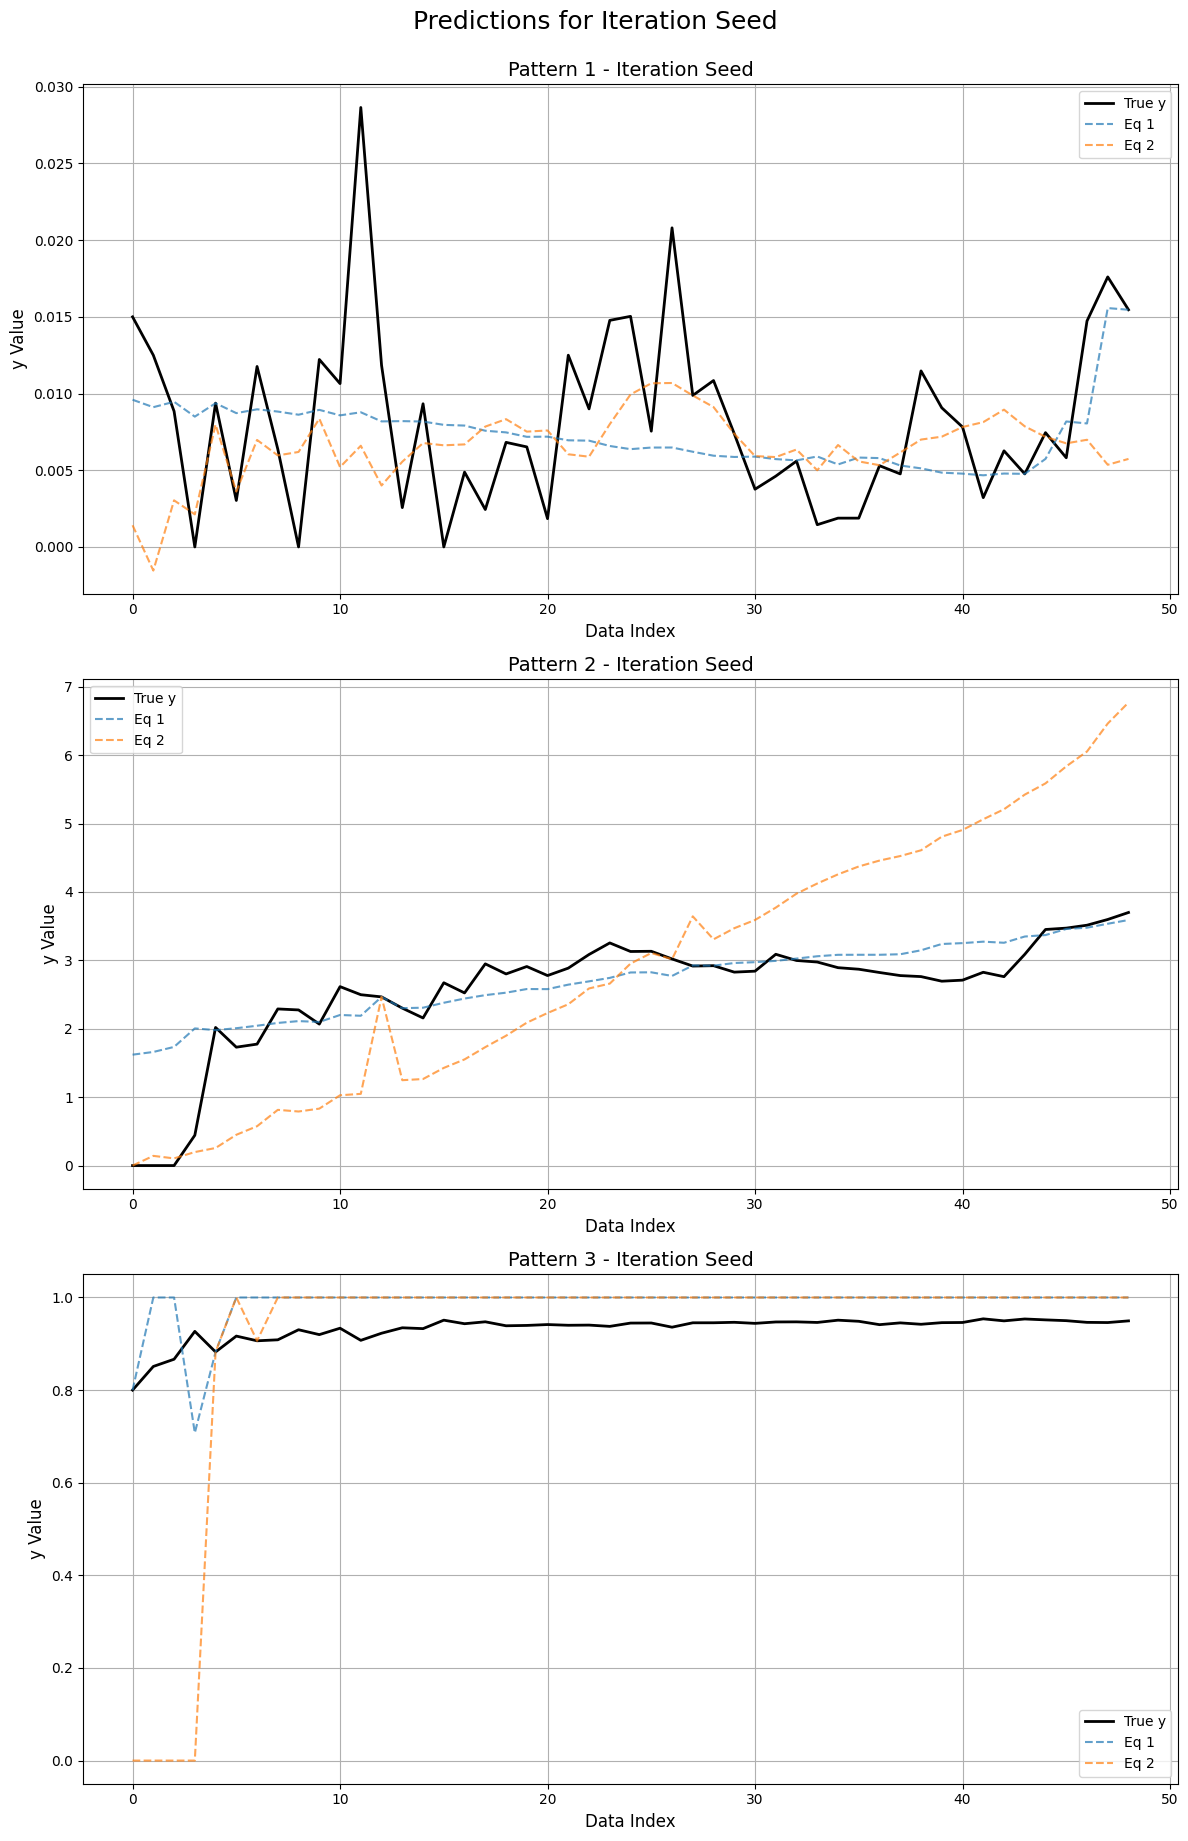

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1 Analysis:
- The dependent variable (y) exhibits oscillating behavior, possibly due to the complex interaction between vehicles, UAVs, and junction counts.
- It seems reasonable to start with polynomial terms, considering the relationships between density and compute load.
- Logarithmic or exponential terms might capture the saturation effects or sudden changes due to congestion.
- Moving averages might smooth out oscillations for prediction.

Pattern 2 Analysis:
- The dependent variable (y) is influenced by density and compute load, suggesting a nonlinear relationship.
- Polynomial terms for density could represent varying communication rates.
- Logarithmic or exponential terms could account for scale effects between density and rate.
- Residual combinations might capture the complex interactions among densities and compute load.

Pattern 3 Analysis:
- The task success ratio (y) needs to be bounded betw

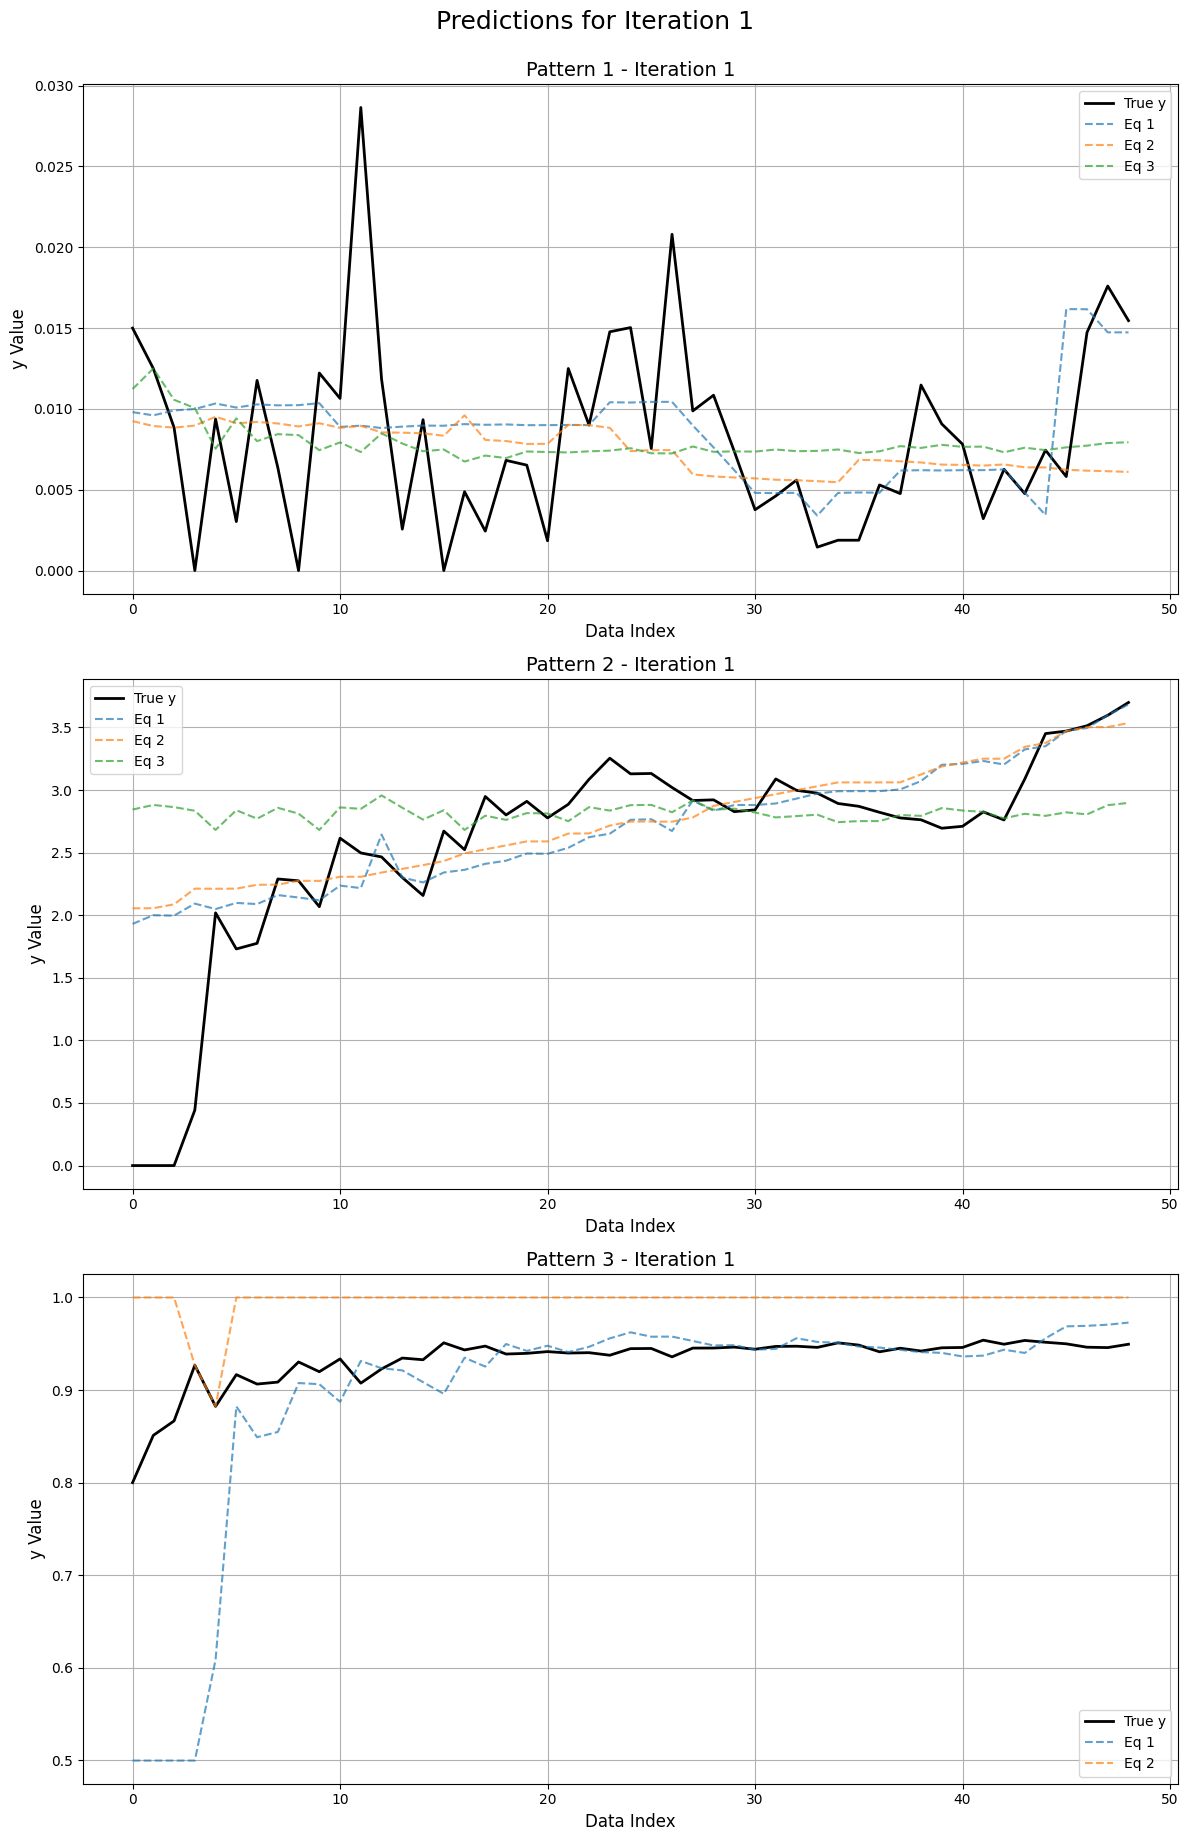

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*x1+c[1]*sqrt(x2)+c[2]*exp(-x3+x4+x5)', 'complexity': 19, 'nmae': np.float64(0.13637087567791478), 'fitted_params': [0.014524449255563513, -0.0038246474793348206, 0.005350779800435597]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+x4+x5)', 'complexity': 20, 'nmae': np.float64(0.15512139507820838), 'fitted_params': [0.054261480500062756, 1.9351954468069446e-05, -0.018380658773995216]}, {'equation': 'c[0]*sqrt(x1)+c[1]*x5+c[2]*x6', 'complexity': 12, 'nmae': np.float64(0.12990565832810322), 'fitted_params': [0.010736833161717457, -0.001409702604629475, 0.007080266962652108]}, {'equation': 'c[0]*x1+c[1]*log(x2)+c[2]*x4', 'complexity': 12, 'nmae': np.float64(0.14640292410975875), 'fitted_params': [0.009119908543684408, -0.0019578890465276055, 0.0013407280956451964]}, {'equation': 'c[0]*x1**2+c[1]*x2+c[2]*x3', 'complexity': 13, 'nmae': np.float64(0.14891625042526058), 'fitted_params': [-0.023308138729949916, 0.000203

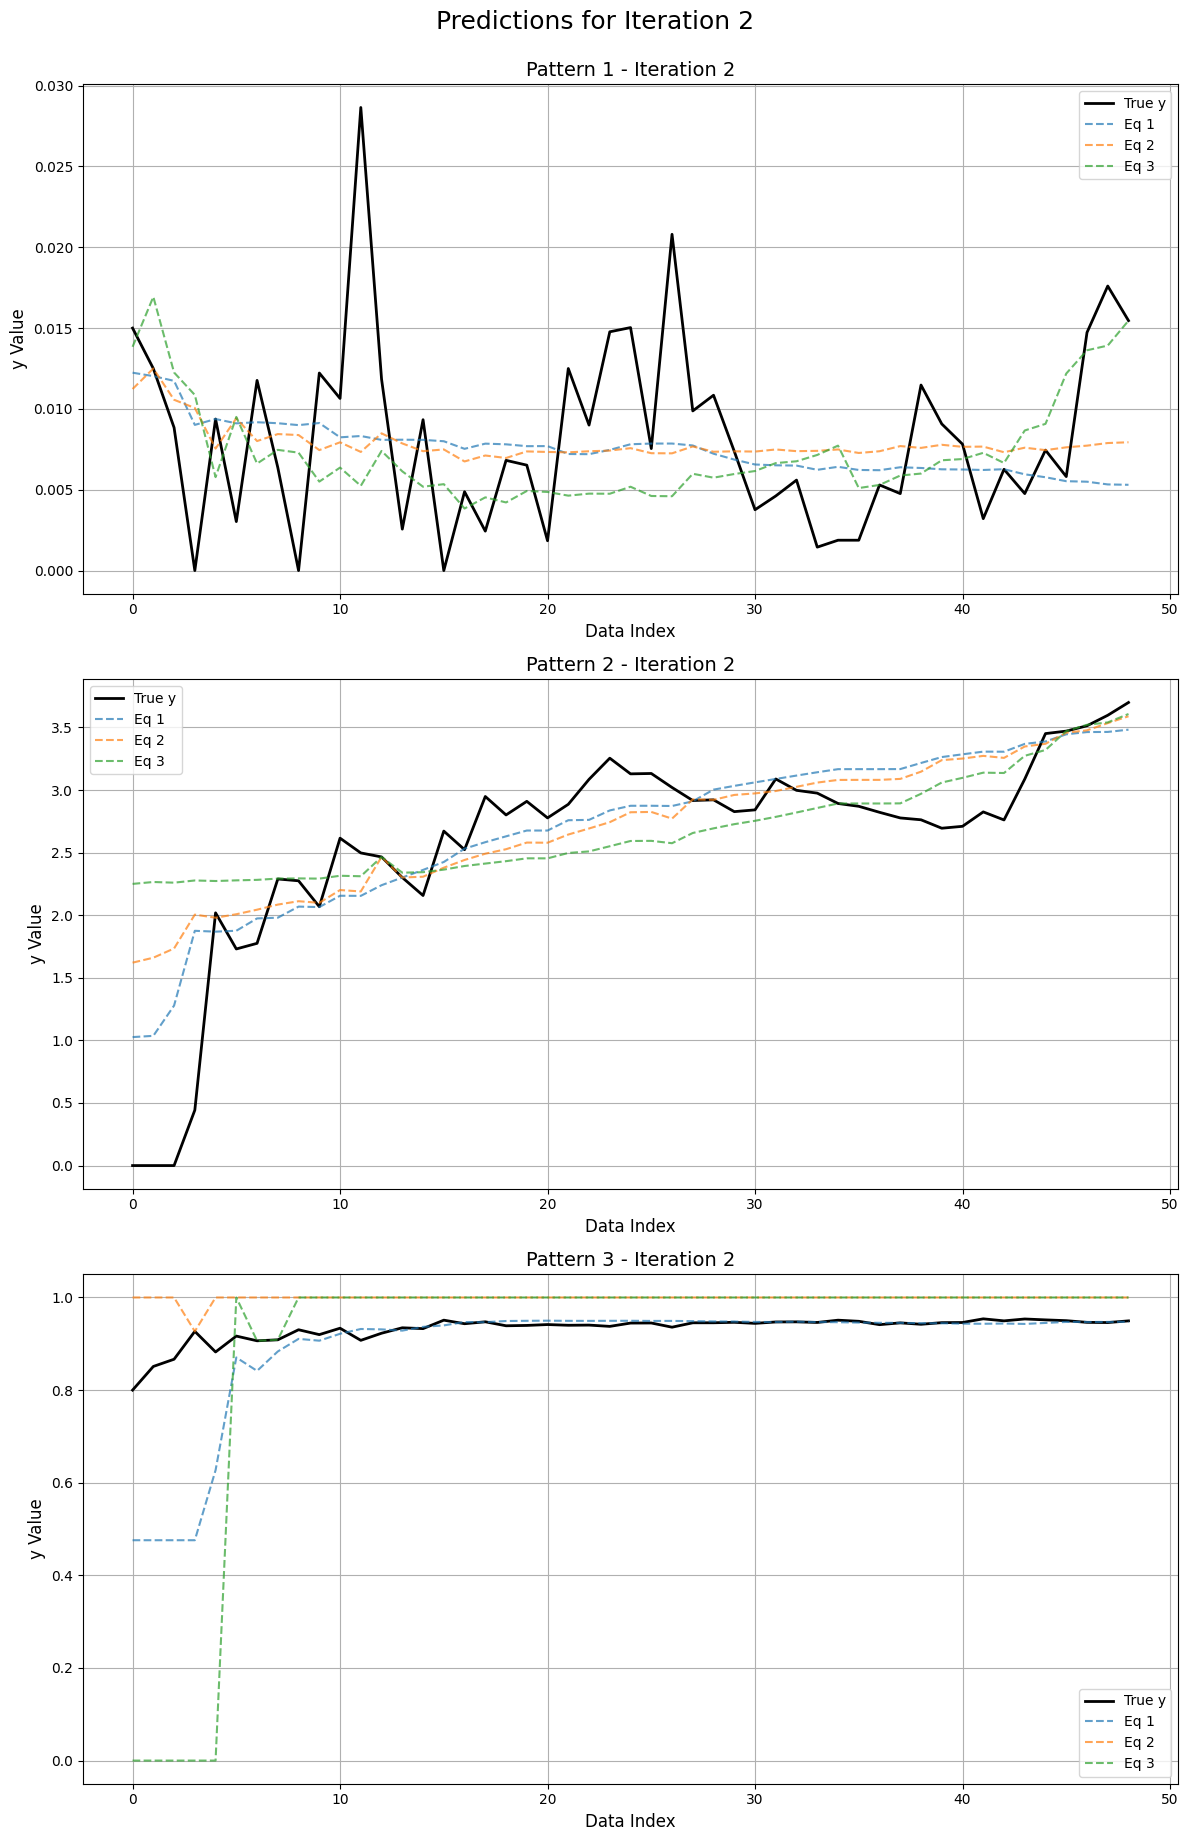

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*log(x1)+c[1]*exp(x2-x4)', 'complexity': 11, 'nmae': np.float64(0.15566081045428304), 'fitted_params': [-0.07573297477359406, 2.2965659096746284e-05]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+x4+x5)', 'complexity': 20, 'nmae': np.float64(0.15512139507820838), 'fitted_params': [0.054261480500062756, 1.9351954468069446e-05, -0.018380658773995216]}, {'equation': 'c[0]*x1**2+c[1]*x2+c[2]*exp(-x3)', 'complexity': 16, 'nmae': np.float64(0.14891571928760342), 'fitted_params': [-0.023278784764296883, 0.00020199184400851897, 36.3544517229558]}, {'equation': 'c[0]*sqrt(x1)+c[1]*log(x2+x4+x5)', 'complexity': 13, 'nmae': np.float64(0.14693244570375363), 'fitted_params': [0.011440728246955252, -0.002139216322732277]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2)+c[2]*exp(-x3+x4+x5)', 'complexity': 19, 'nmae': np.float64(0.13637087567791478), 'fitted_params': [0.014524449255563513, -0.0038246474793348206, 0.005350779800435597]}, 

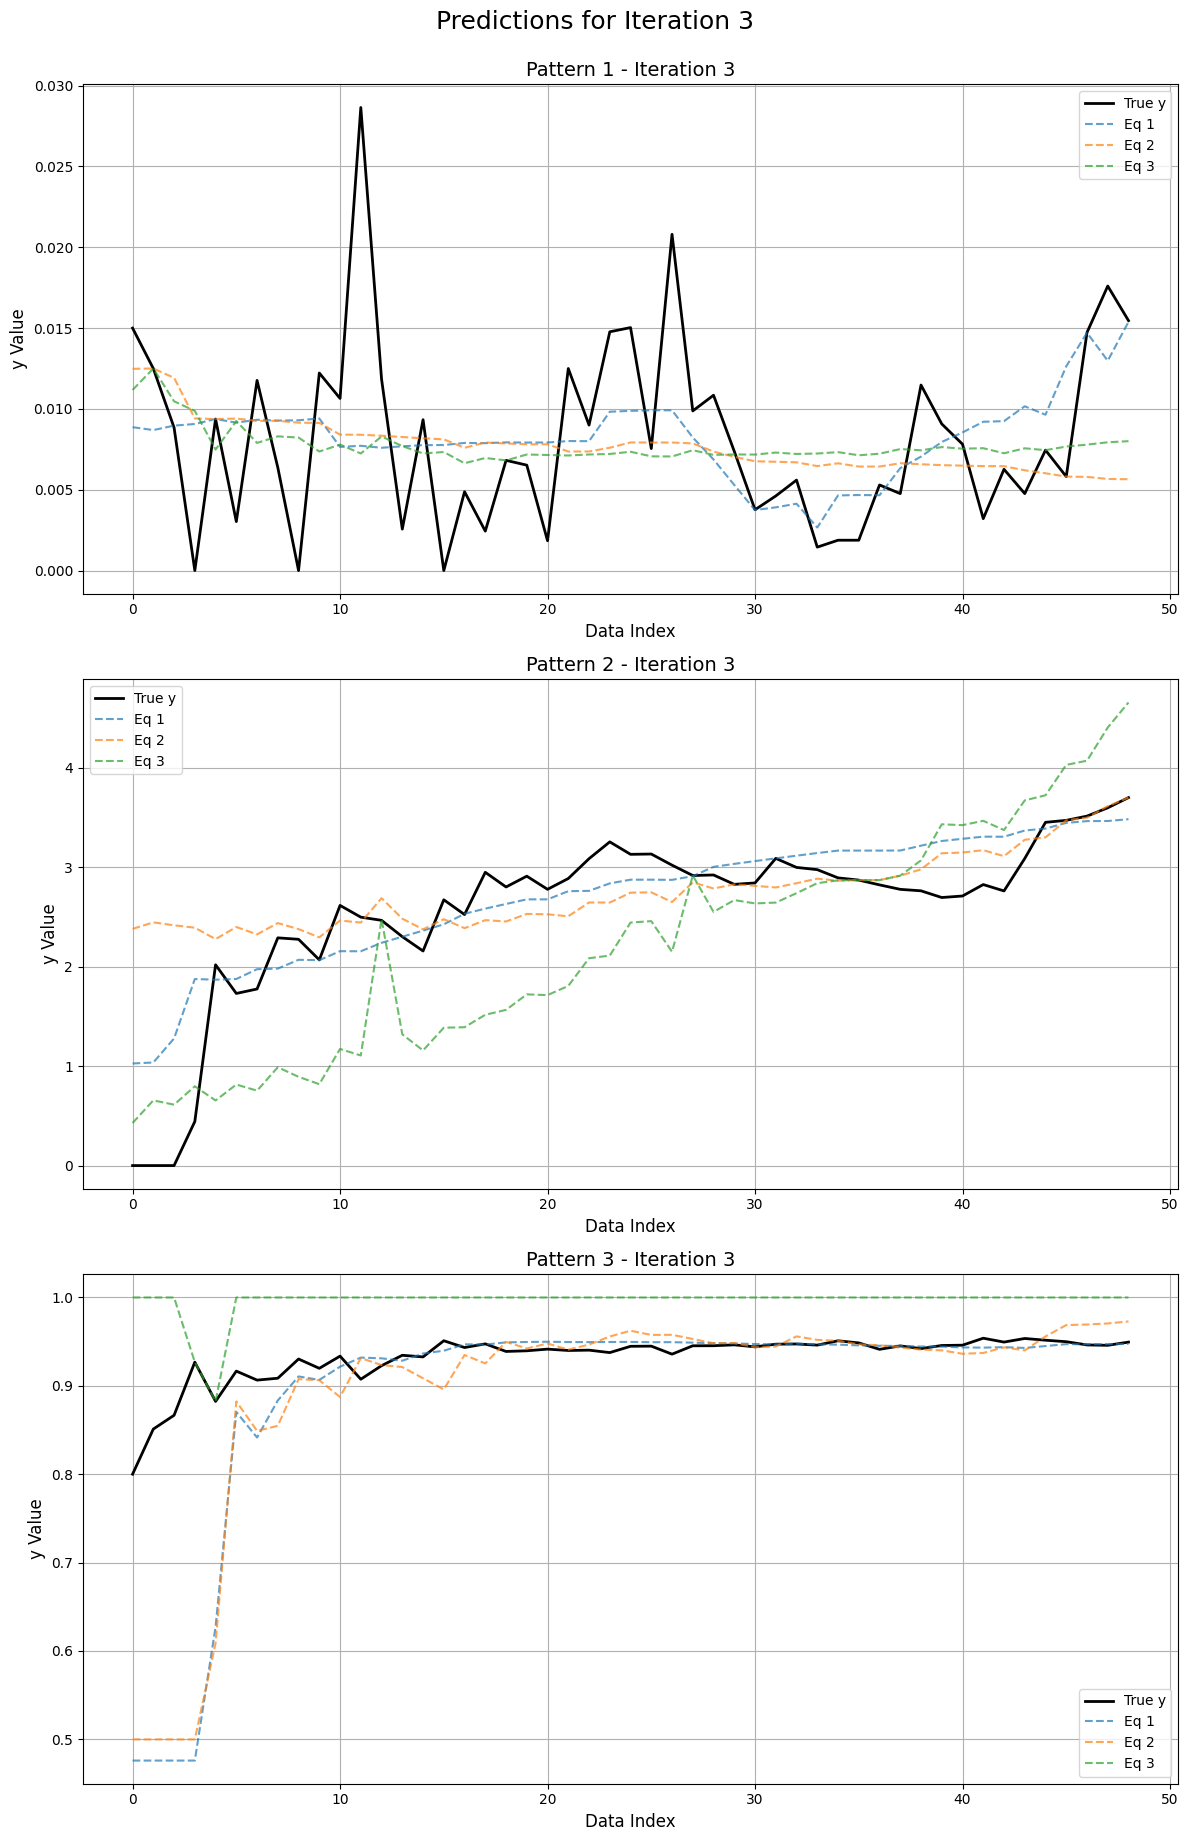

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*log(x1)+c[1]*exp(x2-x4)', 'complexity': 11, 'nmae': np.float64(0.15566081045428304), 'fitted_params': [-0.07573297477359406, 2.2965659096746284e-05]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+x4+x5)', 'complexity': 20, 'nmae': np.float64(0.15512139507820838), 'fitted_params': [0.054261480500062756, 1.9351954468069446e-05, -0.018380658773995216]}, {'equation': 'c[0]*x1**2+c[1]*x2+c[2]*exp(-x3)', 'complexity': 16, 'nmae': np.float64(0.14891571928760342), 'fitted_params': [-0.023278784764296883, 0.00020199184400851897, 36.3544517229558]}, {'equation': 'c[0]*x1**2+c[1]*log(x2+x4+x5)+c[2]*exp(-x3)', 'complexity': 21, 'nmae': np.float64(0.14670572777083604), 'fitted_params': [-0.0003383222458565653, -0.0018995380009218786, 14.802744420719527]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2)+c[2]*exp(-x3+x4+x5)', 'complexity': 19, 'nmae': np.float64(0.13637087567791478), 'fitted_params': [0.014524449255563513, -0.00382464747

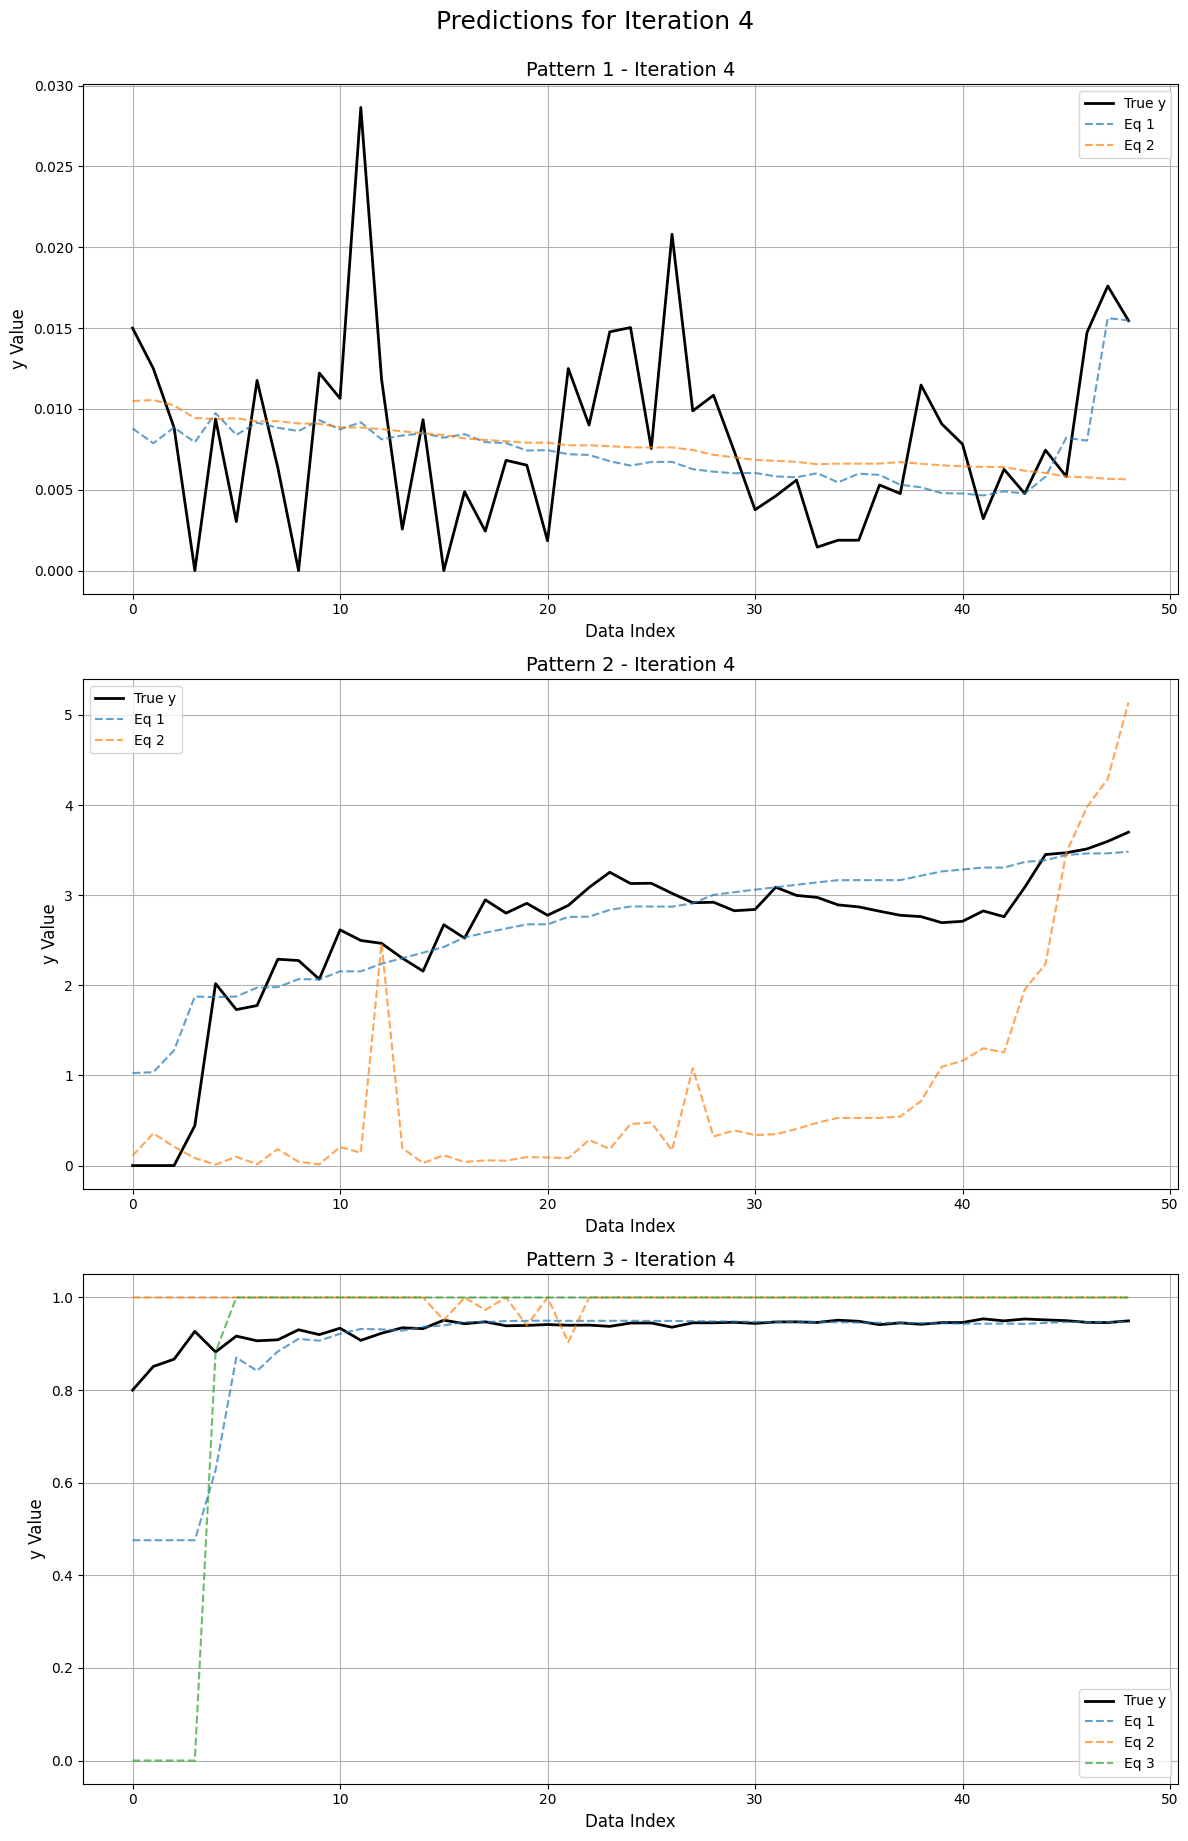

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*log(x1)+c[1]*exp(x2-x4)', 'complexity': 11, 'nmae': np.float64(0.15566081045428304), 'fitted_params': [-0.07573297477359406, 2.2965659096746284e-05]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+x4+x5)', 'complexity': 20, 'nmae': np.float64(0.15512139507820838), 'fitted_params': [0.054261480500062756, 1.9351954468069446e-05, -0.018380658773995216]}, {'equation': 'c[0]*log(x1+x2)+c[1]*x3**2+c[2]*x5', 'complexity': 16, 'nmae': np.float64(0.14889289456292243), 'fitted_params': [-0.0022447099303671814, 0.00021287395654432227, -9.574299886076716e-05]}, {'equation': 'c[0]*x1**2+c[1]*sqrt(x2)+c[2]*exp(-x3+x4+x5)', 'complexity': 21, 'nmae': np.float64(0.13700996995258632), 'fitted_params': [0.016777156278548692, -0.00435925153727847, 0.005431343552587422]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2)+c[2]*exp(-x3+x4+x5)', 'complexity': 19, 'nmae': np.float64(0.13637087567791478), 'fitted_params': [0.014524449255563513, -0.003

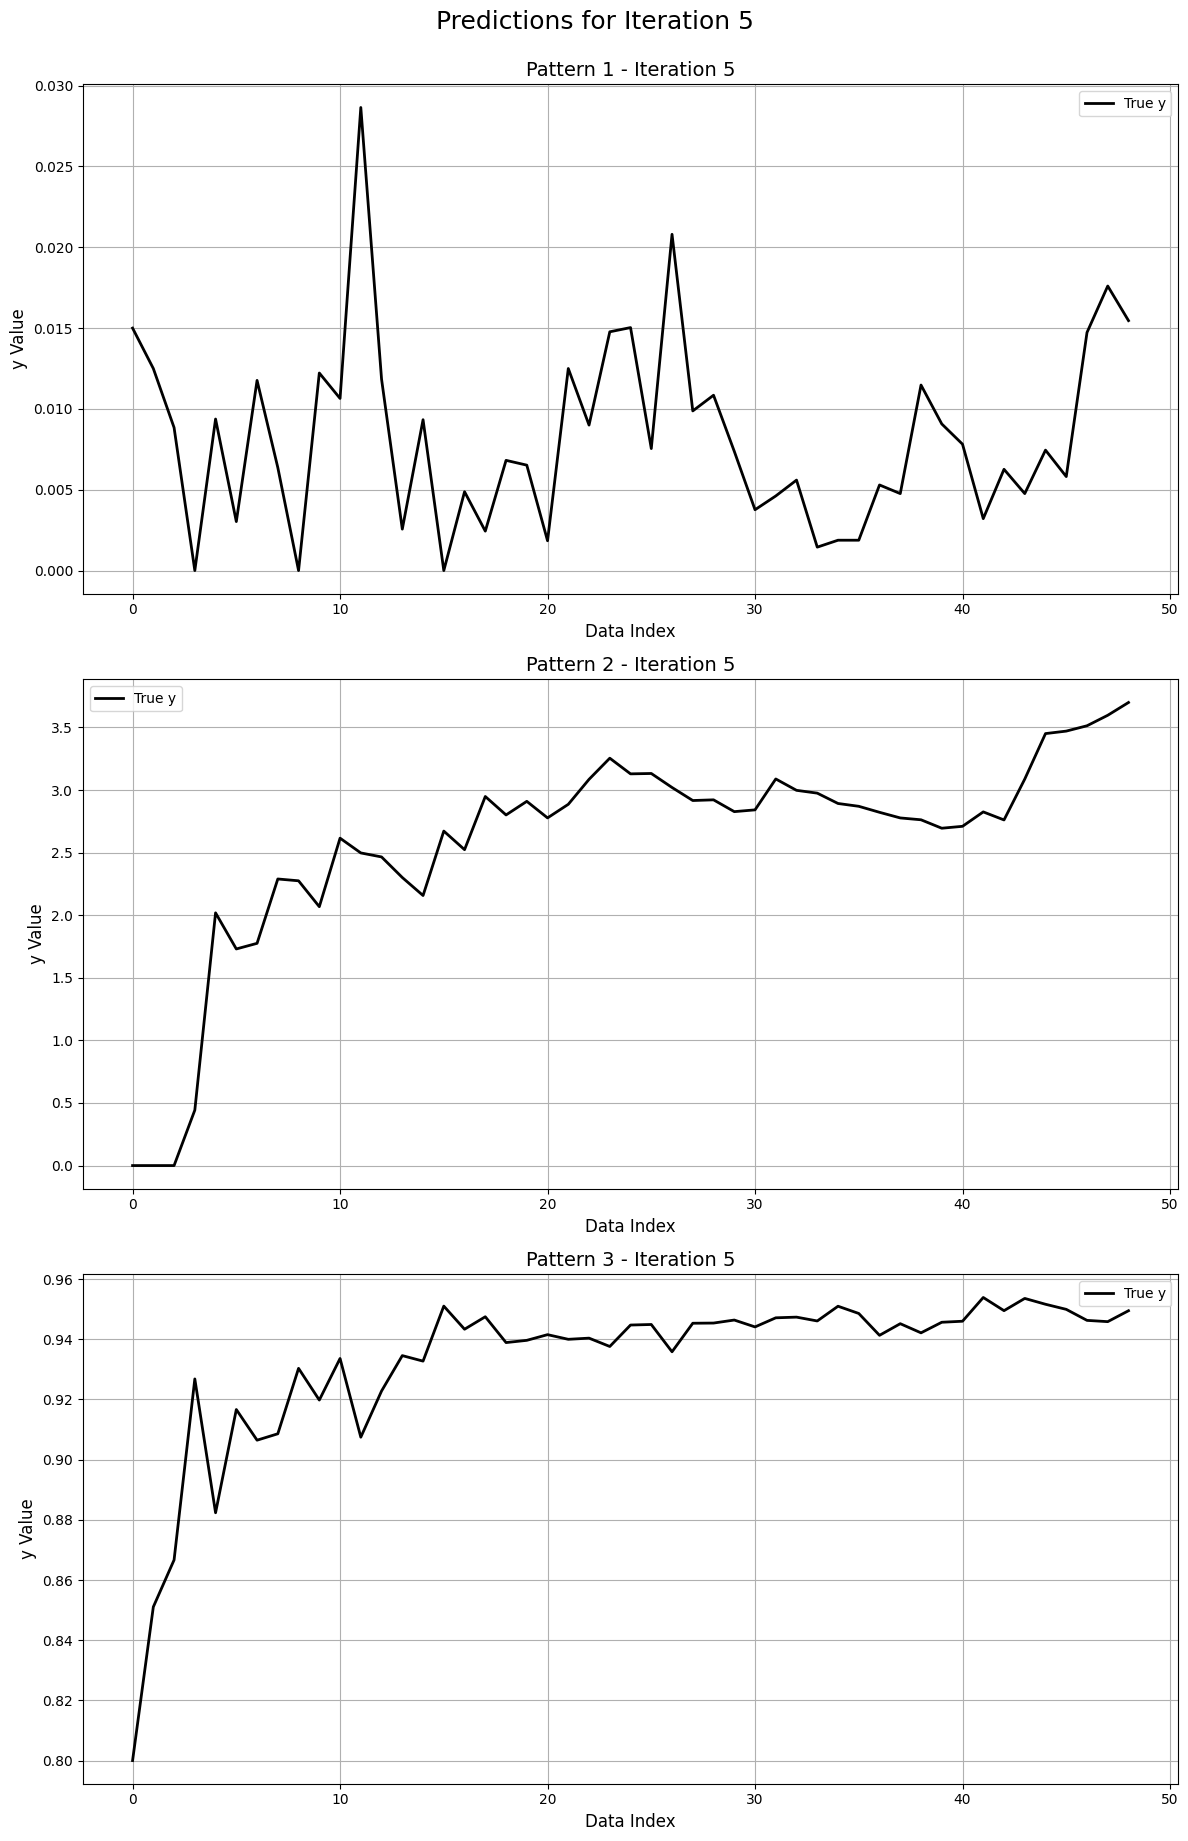

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]*log(x1)+c[1]*exp(x2-x4)', 'complexity': 11, 'nmae': np.float64(0.15566081045428304), 'fitted_params': [-0.07573297477359406, 2.2965659096746284e-05]}, {'equation': 'c[0]*x1**2+c[1]*x2**3+c[2]*log(x3+x4+x5)', 'complexity': 20, 'nmae': np.float64(0.15512139507820838), 'fitted_params': [0.054261480500062756, 1.9351954468069446e-05, -0.018380658773995216]}, {'equation': 'c[0]*log(x1+x2)+c[1]*x3**2+c[2]*x5', 'complexity': 16, 'nmae': np.float64(0.14889289456292243), 'fitted_params': [-0.0022447099303671814, 0.00021287395654432227, -9.574299886076716e-05]}, {'equation': 'c[0]*x1**2+c[1]*sqrt(x2)+c[2]*exp(-x3+x4+x5)', 'complexity': 21, 'nmae': np.float64(0.13700996995258632), 'fitted_params': [0.016777156278548692, -0.00435925153727847, 0.005431343552587422]}, {'equation': 'c[0]*x1+c[1]*sqrt(x2)+c[2]*exp(-x3+x4+x5)', 'complexity': 19, 'nmae': np.float64(0.13637087567791478), 'fitted_params': [0.014524449255563513, -0.003

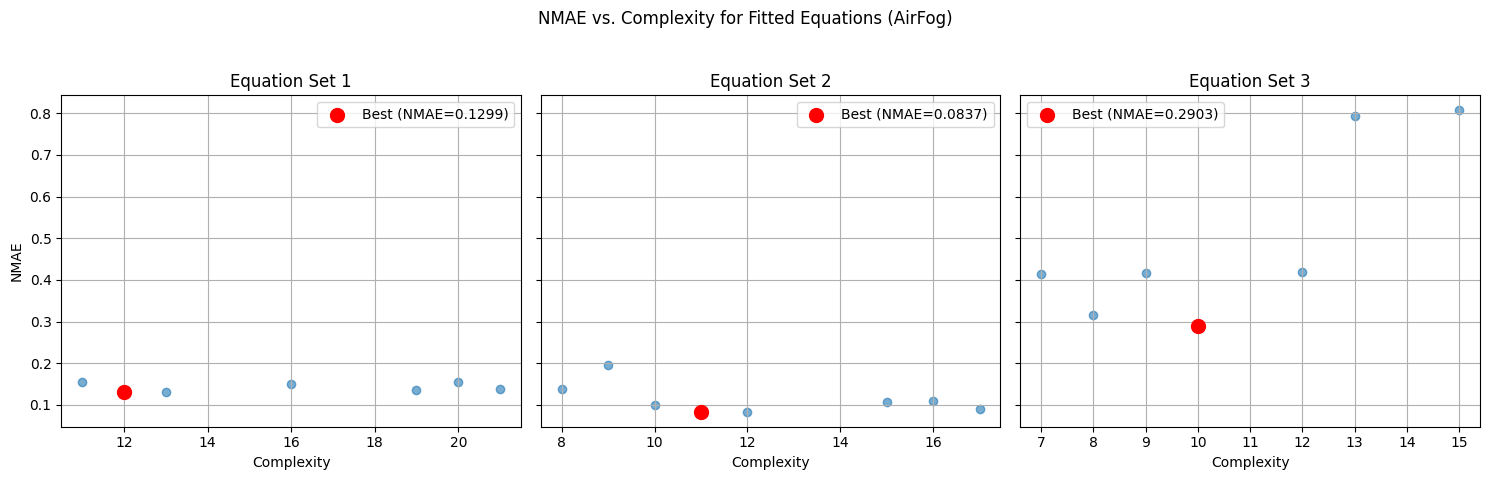

Experiment 1 finished.
Running experiment 2...


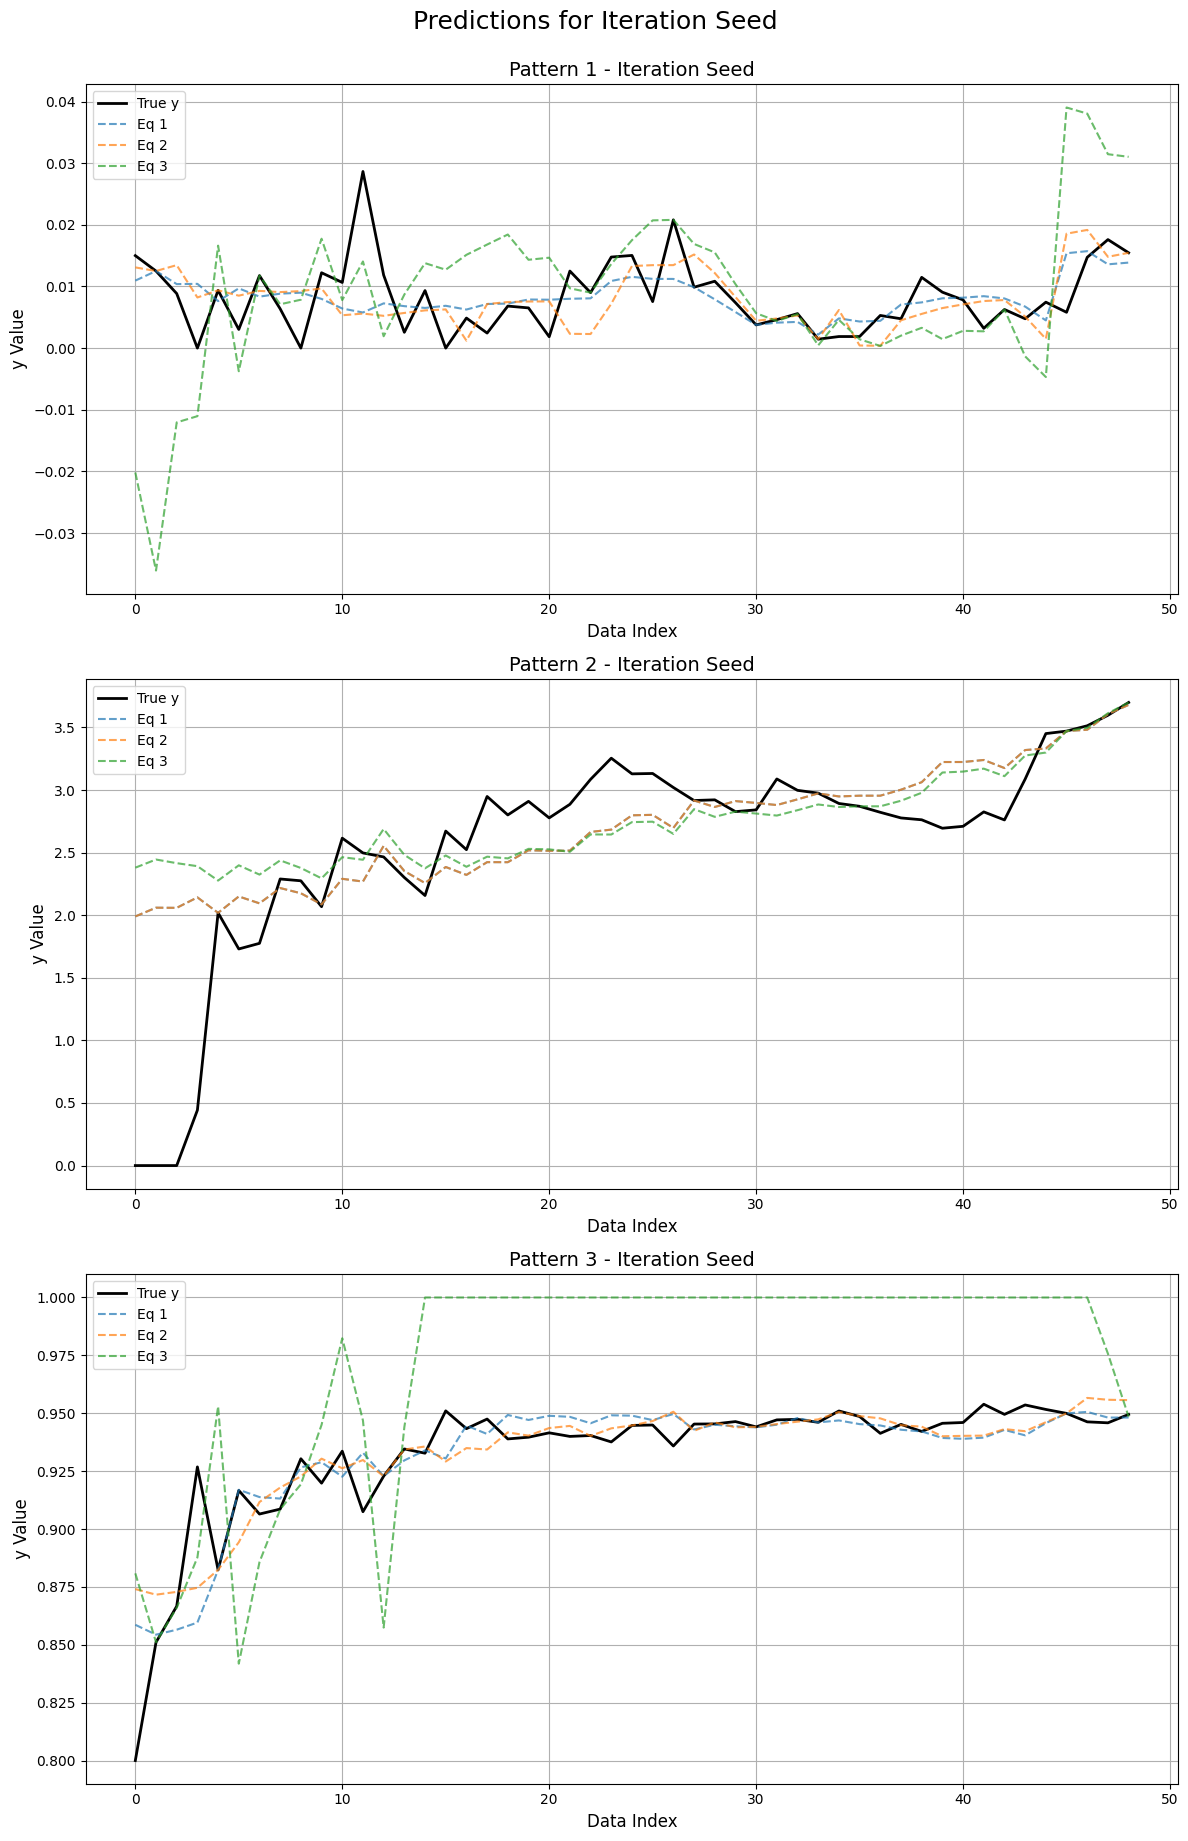

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:
1. Pattern 1 Analysis:
- Dependent variable: Average compute load.
- Independent variables: Task success ratio, vehicle density, UAV density, and vehicle counts at three junctions.
- Observations: 
  - The average compute load seems influenced by a mix of density and success ratios, likely needing polynomial terms.
  - Possible non-linear relationships can be modeled using polynomials or log transformations.

2. Pattern 2 Analysis:
- Dependent variable: Average V2U rate.
- Independent variables: Vehicle density, UAV density, compute load.
- Observations:
  - The V2U rate is likely influenced by both densities and compute load.
  - Can explore multiplicative interactions or polynomial terms to capture the non-linearity.

3. Pattern 3 Analysis:
- Dependent variable: Task success ratio.
- Independent variables: V2U rate, V2I rate, compute load.
- Observations:
  - Task success ratio should be bounded be

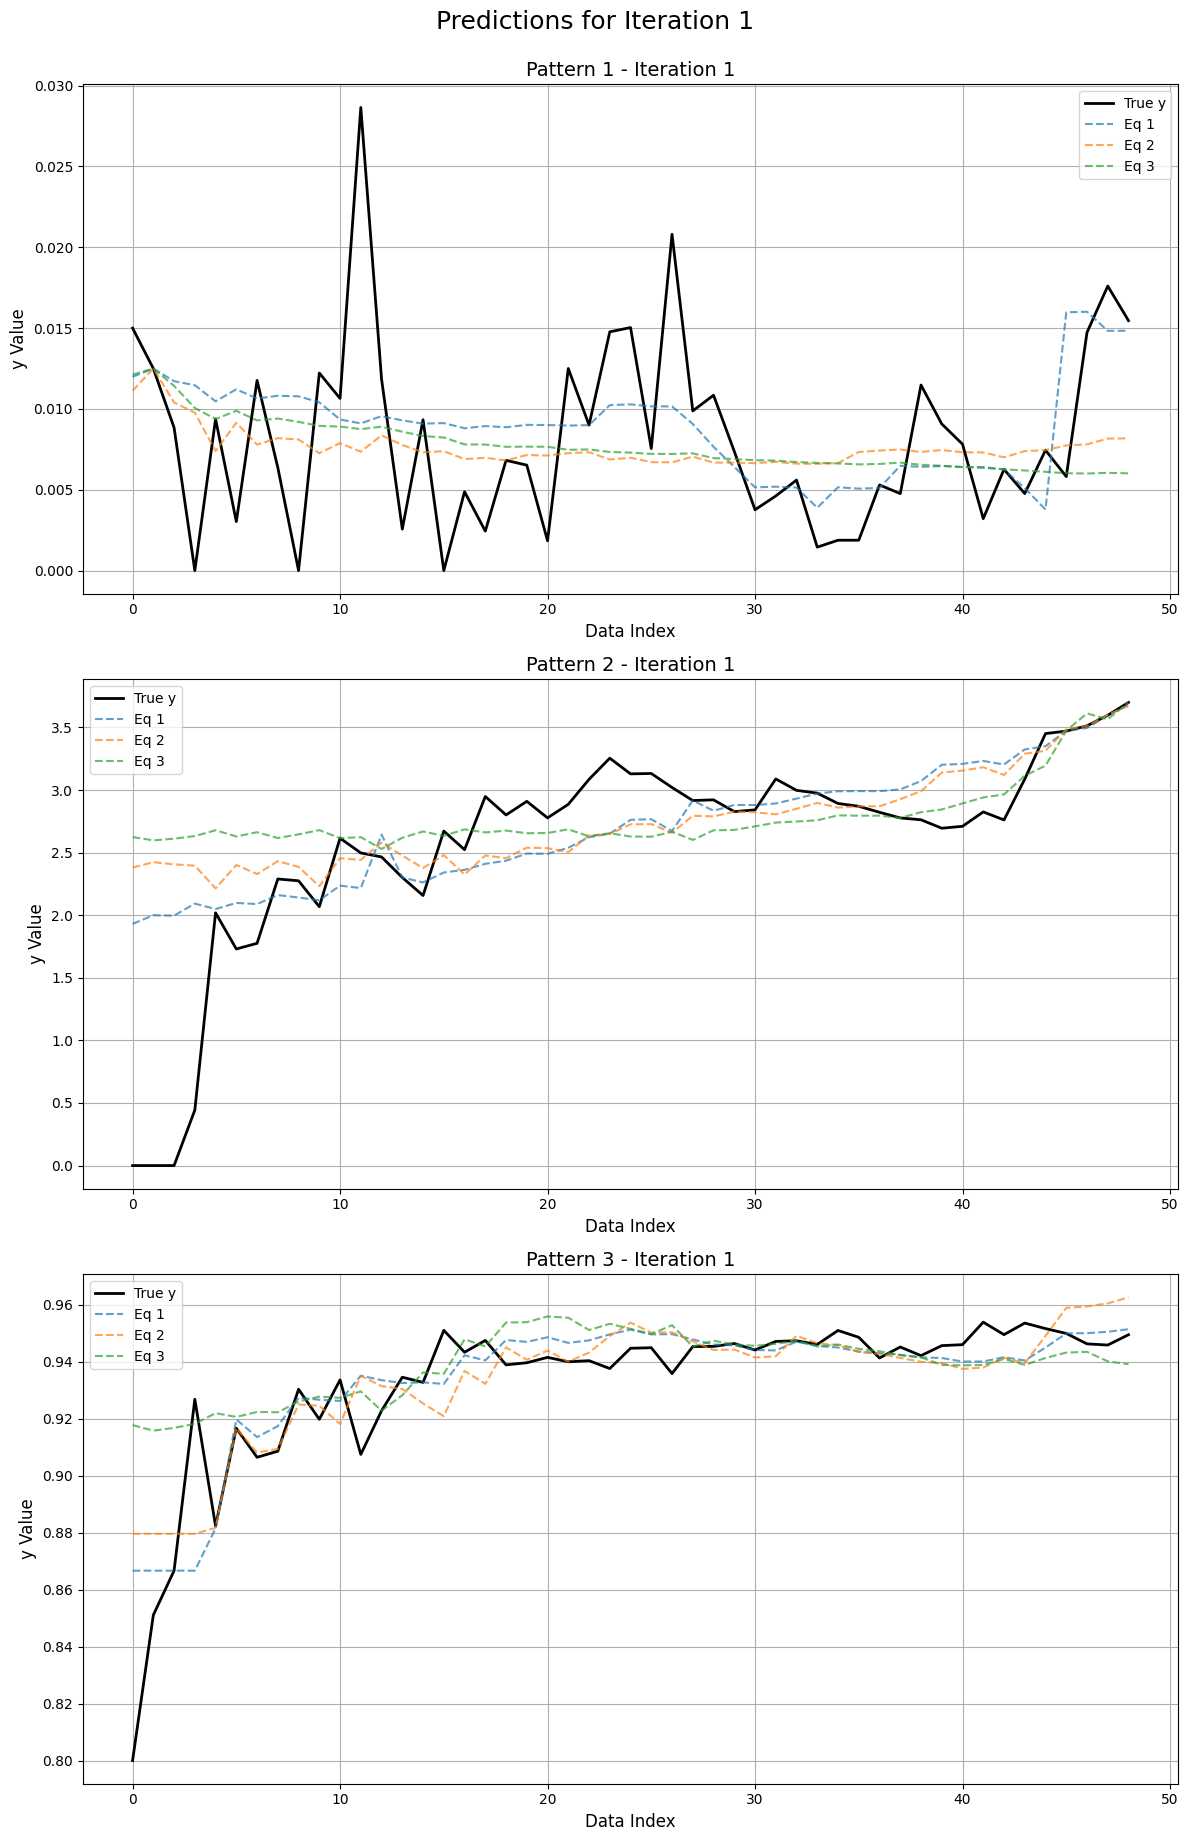

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(1+c[1]*x1)+c[2]*x2+c[3]*x3**2+c[4]*x4+c[5]*x5+c[6]*x6', 'complexity': 30, 'nmae': np.float64(0.3028252641986604), 'fitted_params': [-266.03896542185737, 0.781944443465824, -0.0016289376776578621, 5.130739876214937, -0.005351125974389614, -0.0049383458077340275, 0.025114004067474688]}, {'equation': 'c[0]+c[1]*sqrt(x1)+c[2]*x4*x5', 'complexity': 12, 'nmae': np.float64(0.14802350517819432), 'fitted_params': [0.07934104178109698, -0.0747299052195872, 0.00021708056975482256]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x2**2+c[3]*x3+c[4]*x4+c[5]*x5+c[6]*x6', 'complexity': 29, 'nmae': np.float64(0.14330932908585023), 'fitted_params': [7.452114442770438, 0.010747888373578755, 0.00032061323985500145, -1.0351377245976416, -0.0058528870728912375, -0.004284570298828694, 0.009763933475994436]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x5+c[3]*exp(x6)', 'complexity': 16, 'nmae': np.float64(0.1293147839105414), 'fitted_params': [0.016318

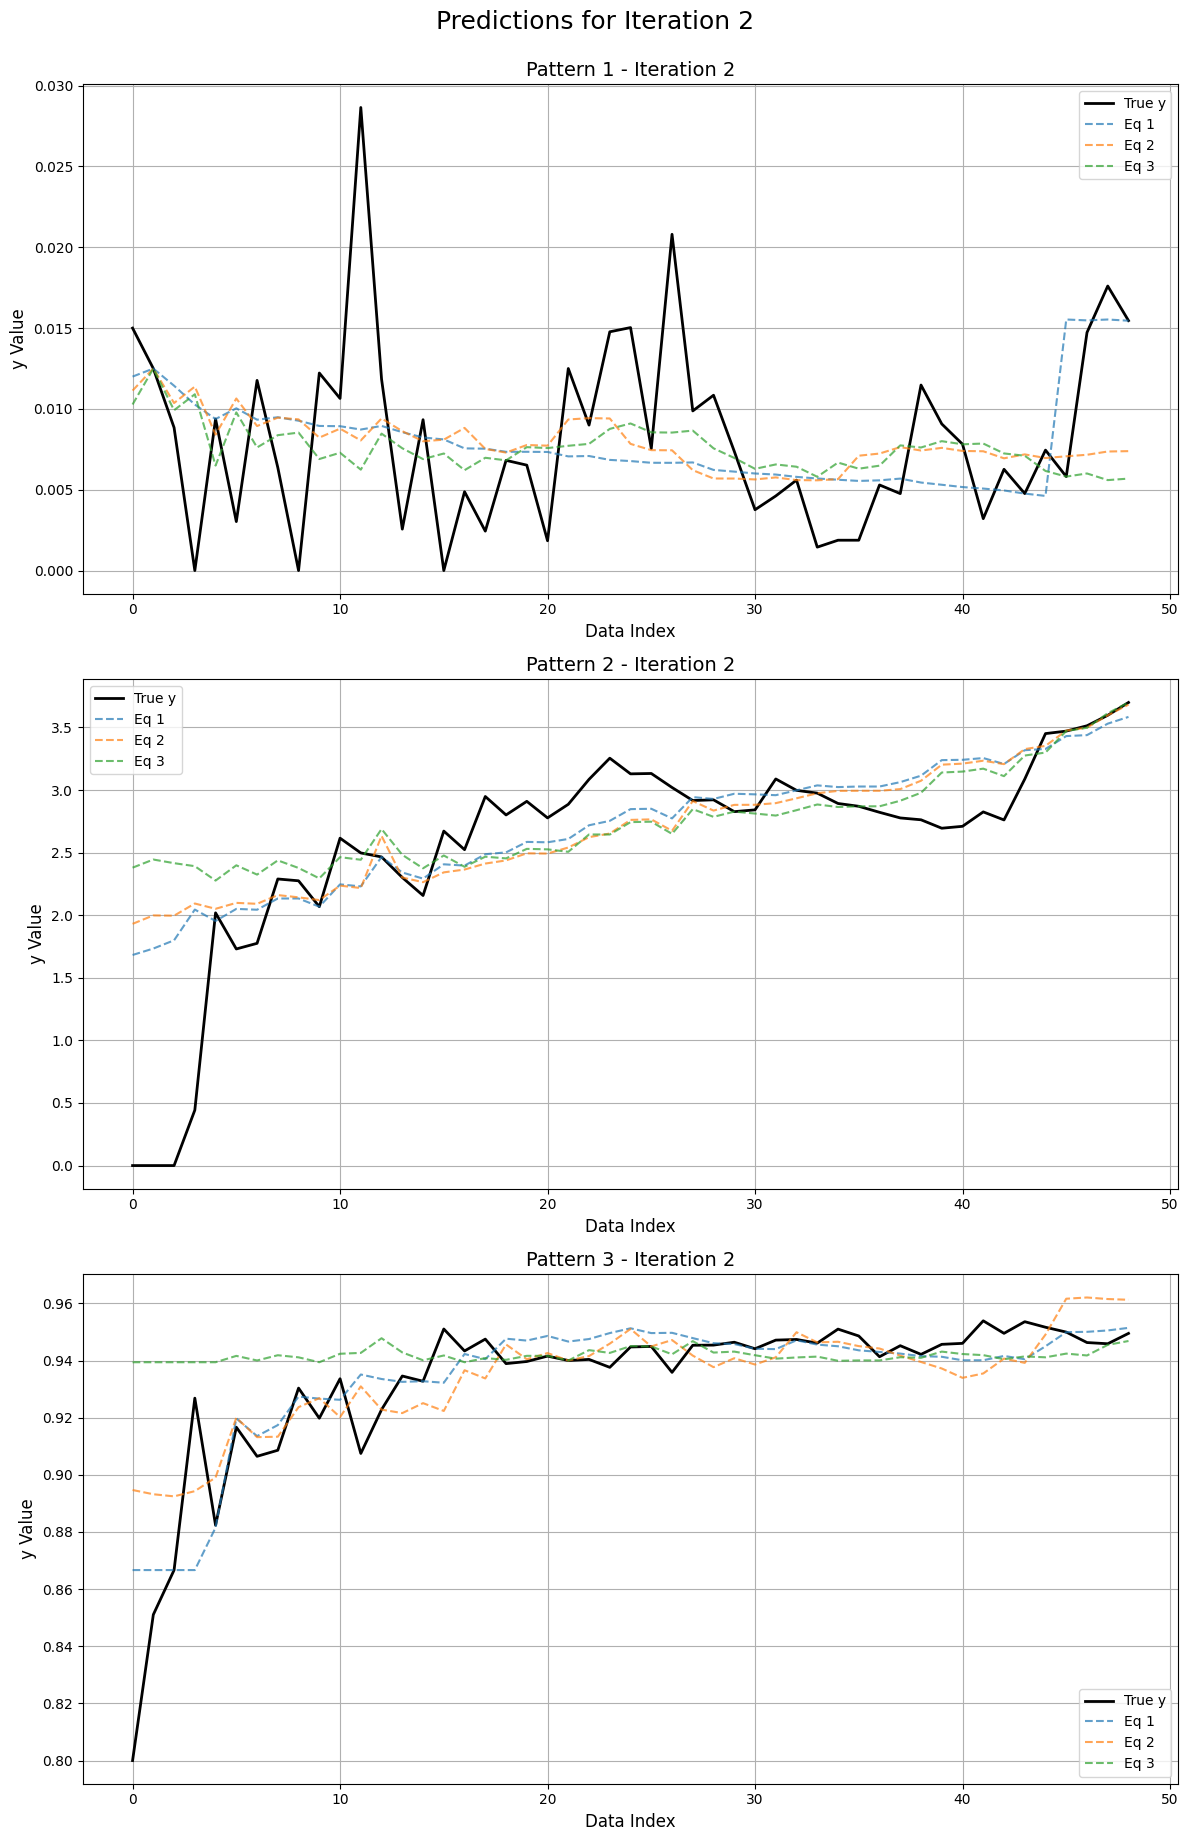

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(1+c[1]*x1)+c[2]*x2+c[3]*x3**2+c[4]*x4+c[5]*x5+c[6]*x6', 'complexity': 30, 'nmae': np.float64(0.3028252641986604), 'fitted_params': [-266.03896542185737, 0.781944443465824, -0.0016289376776578621, 5.130739876214937, -0.005351125974389614, -0.0049383458077340275, 0.025114004067474688]}, {'equation': 'c[0]+c[1]*sqrt(x1)+c[2]*x4*x5', 'complexity': 12, 'nmae': np.float64(0.14802350517819432), 'fitted_params': [0.07934104178109698, -0.0747299052195872, 0.00021708056975482256]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x2**2+c[3]*x3+c[4]*x4+c[5]*x5+c[6]*x6', 'complexity': 29, 'nmae': np.float64(0.14330932908585023), 'fitted_params': [7.452114442770438, 0.010747888373578755, 0.00032061323985500145, -1.0351377245976416, -0.0058528870728912375, -0.004284570298828694, 0.009763933475994436]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x5+c[3]*exp(x6)', 'complexity': 16, 'nmae': np.float64(0.1293147839105414), 'fitted_params': [0.016318

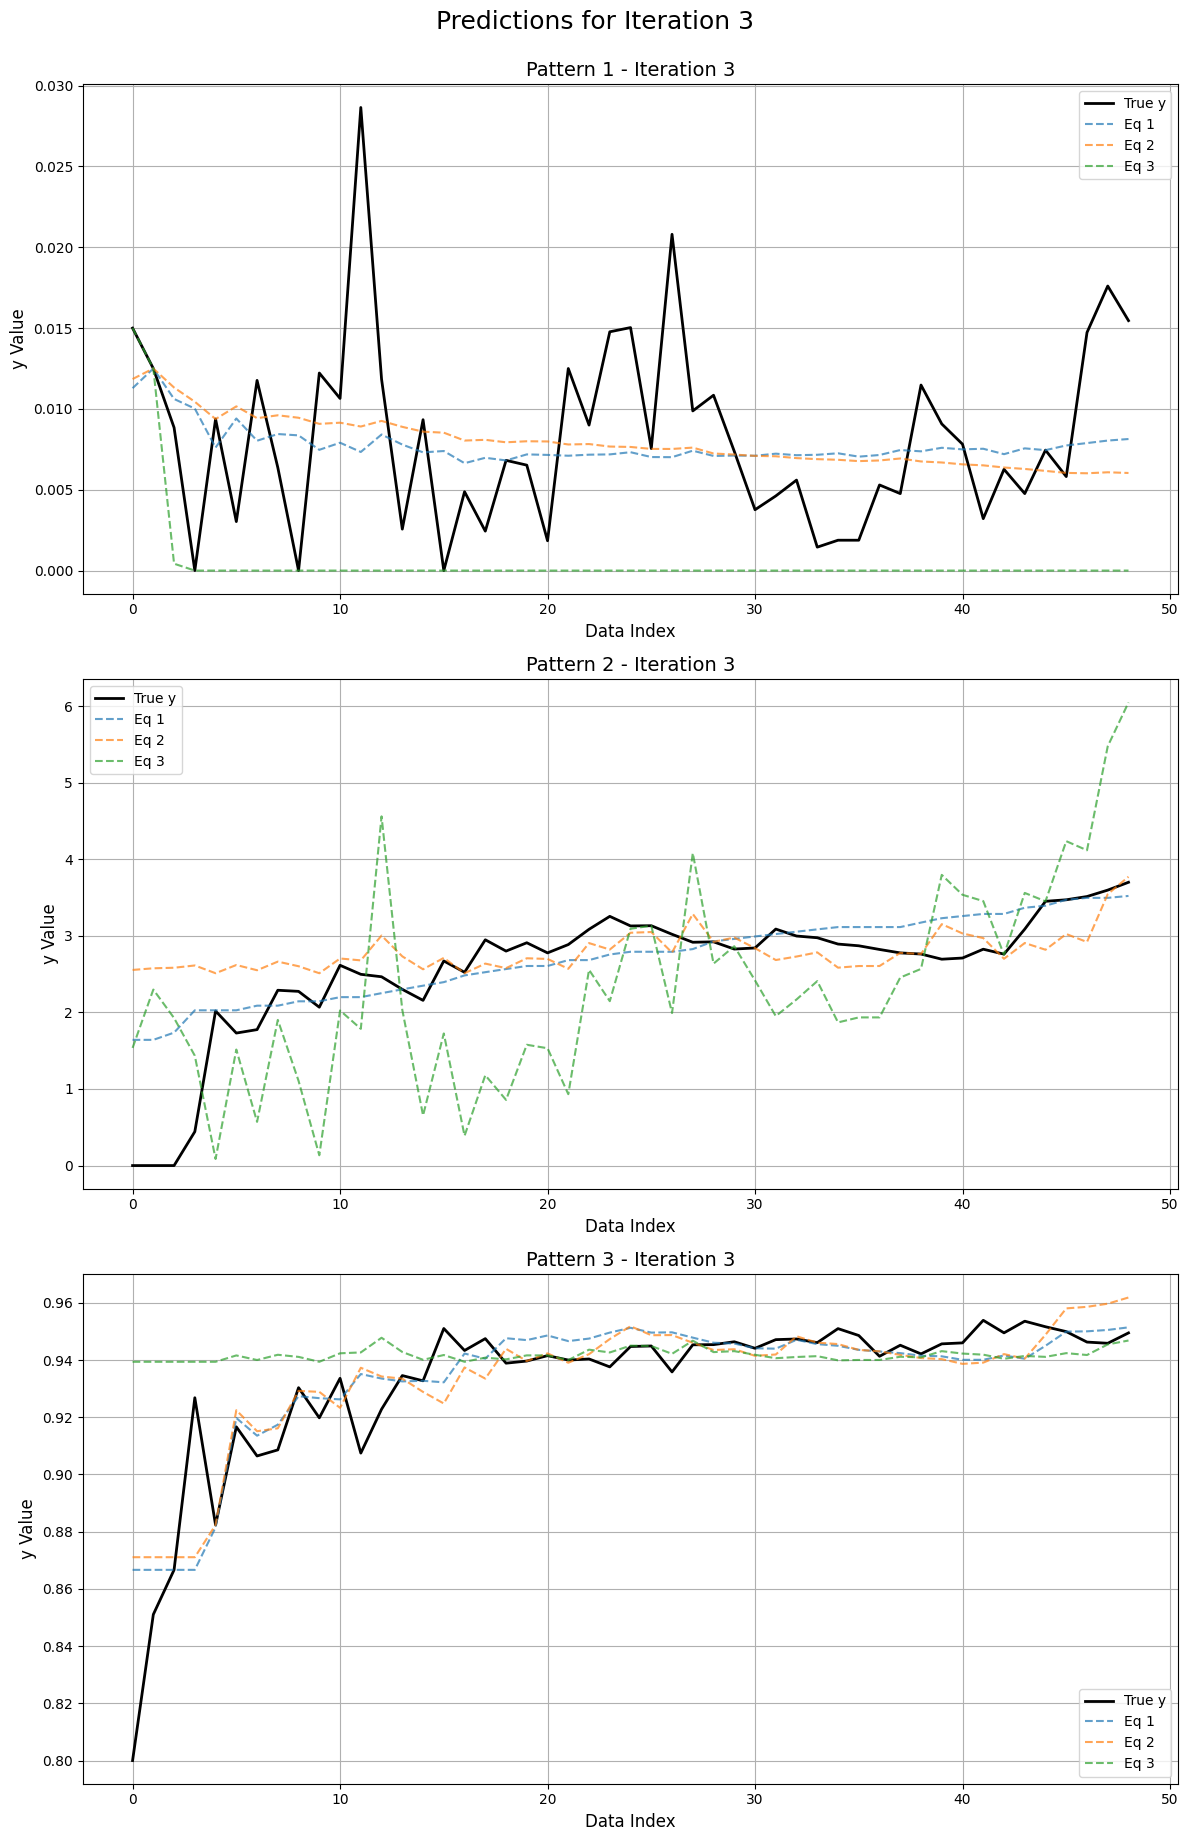

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(1+c[1]*x1)+c[2]*x2+c[3]*x3**2+c[4]*x4+c[5]*x5+c[6]*x6', 'complexity': 30, 'nmae': np.float64(0.3028252641986604), 'fitted_params': [-266.03896542185737, 0.781944443465824, -0.0016289376776578621, 5.130739876214937, -0.005351125974389614, -0.0049383458077340275, 0.025114004067474688]}, {'equation': 'c[0]*exp(c[1]*x1+c[2]*x2)', 'complexity': 10, 'nmae': np.float64(0.26883356334666125), 'fitted_params': [9.23472454566108, 5.469643318233599, -25.440314185125278]}, {'equation': 'c[0]+c[1]*log(x1)+c[2]*sqrt(x2)', 'complexity': 11, 'nmae': np.float64(0.14865905412221533), 'fitted_params': [0.010169705811692409, -0.015952502399480338, -0.001871709697979258]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x2**3', 'complexity': 13, 'nmae': np.float64(0.14831665507760491), 'fitted_params': [0.026798814618936673, -0.022343472319571536, 3.571294997658466e-06]}, {'equation': 'c[0]+c[1]*sqrt(x1)+c[2]*x4*x5', 'complexity': 12, 'nmae': n

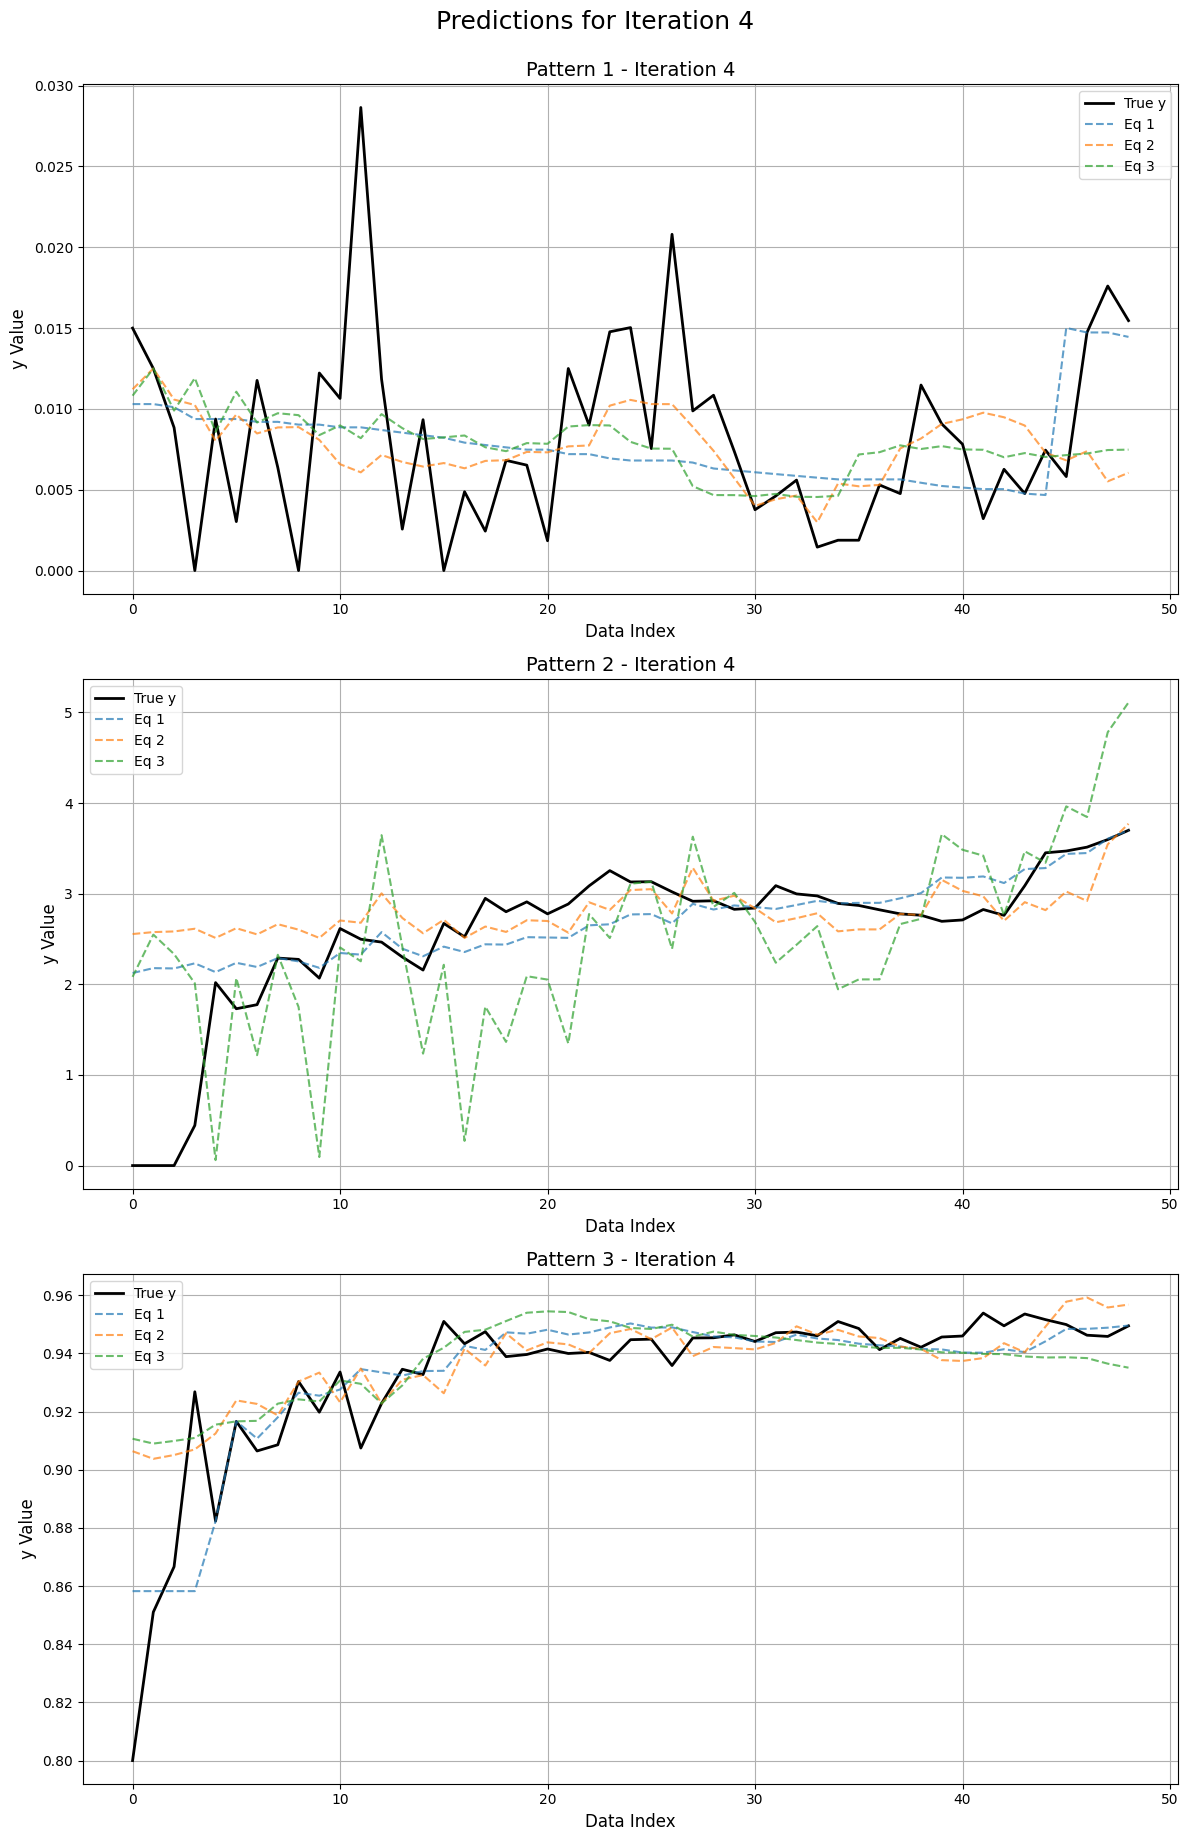

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(1+c[1]*x1)+c[2]*x2+c[3]*x3**2+c[4]*x4+c[5]*x5+c[6]*x6', 'complexity': 30, 'nmae': np.float64(0.3028252641986604), 'fitted_params': [-266.03896542185737, 0.781944443465824, -0.0016289376776578621, 5.130739876214937, -0.005351125974389614, -0.0049383458077340275, 0.025114004067474688]}, {'equation': 'c[0]+c[1]*log(x1)+c[2]*sqrt(x2)', 'complexity': 11, 'nmae': np.float64(0.14865905412221533), 'fitted_params': [0.010169705811692409, -0.015952502399480338, -0.001871709697979258]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x2**3', 'complexity': 13, 'nmae': np.float64(0.14831665507760491), 'fitted_params': [0.026798814618936673, -0.022343472319571536, 3.571294997658466e-06]}, {'equation': 'c[0]+c[1]*sqrt(x1)+c[2]*x4*x5', 'complexity': 12, 'nmae': np.float64(0.14802350517819432), 'fitted_params': [0.07934104178109698, -0.0747299052195872, 0.00021708056975482256]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x3+c[3]*(x4)**0.5', 'compl

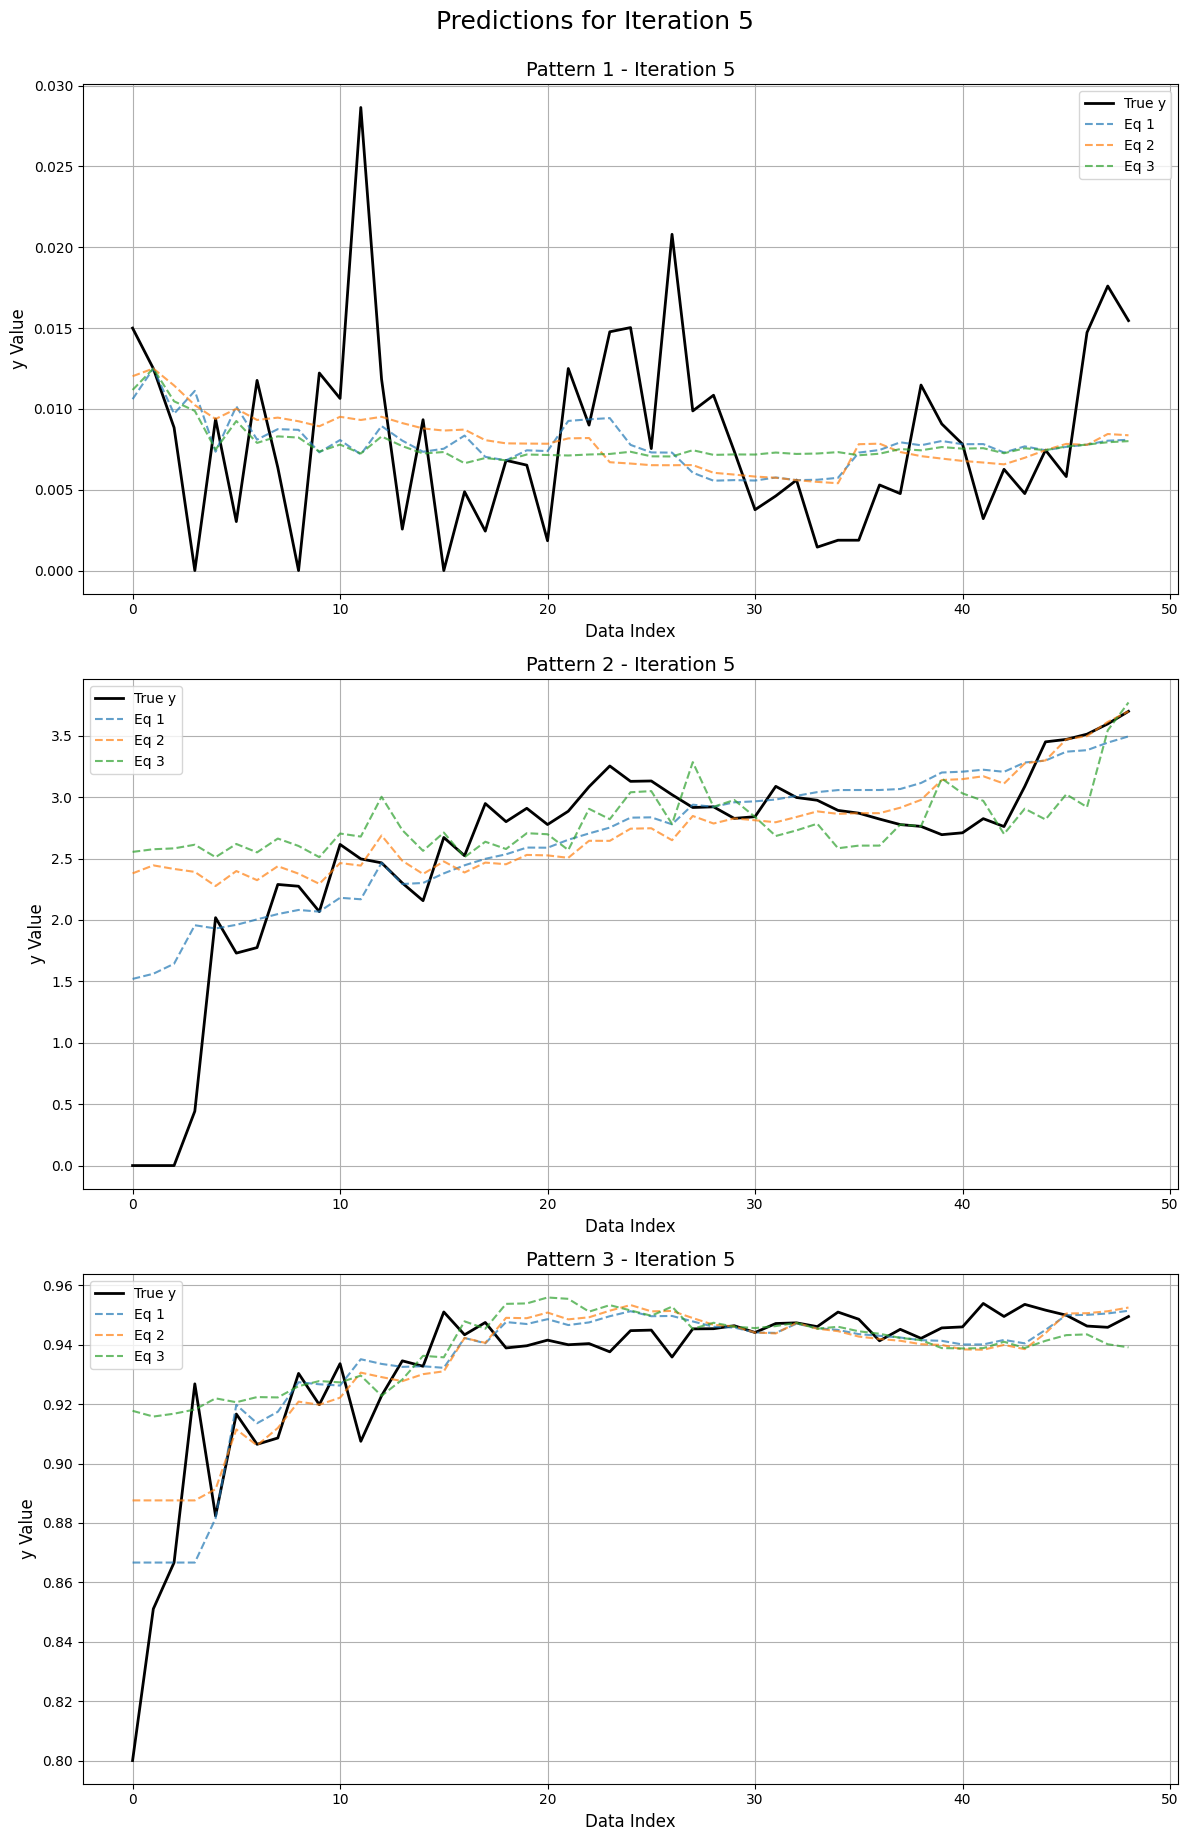

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'c[0]+log(1+c[1]*x1)+c[2]*x2+c[3]*x3**2+c[4]*x4+c[5]*x5+c[6]*x6', 'complexity': 30, 'nmae': np.float64(0.3028252641986604), 'fitted_params': [-266.03896542185737, 0.781944443465824, -0.0016289376776578621, 5.130739876214937, -0.005351125974389614, -0.0049383458077340275, 0.025114004067474688]}, {'equation': 'c[0]+c[1]*log(x1)+c[2]*sqrt(x2)', 'complexity': 11, 'nmae': np.float64(0.14865905412221533), 'fitted_params': [0.010169705811692409, -0.015952502399480338, -0.001871709697979258]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x2**3', 'complexity': 13, 'nmae': np.float64(0.14831665507760491), 'fitted_params': [0.026798814618936673, -0.022343472319571536, 3.571294997658466e-06]}, {'equation': 'c[0]+c[1]*sqrt(x1)+c[2]*x4*x5', 'complexity': 12, 'nmae': np.float64(0.14802350517819432), 'fitted_params': [0.07934104178109698, -0.0747299052195872, 0.00021708056975482256]}, {'equation': 'c[0]+c[1]*x1**2+c[2]*x3+c[3]*(x4)**0.5', 'compl

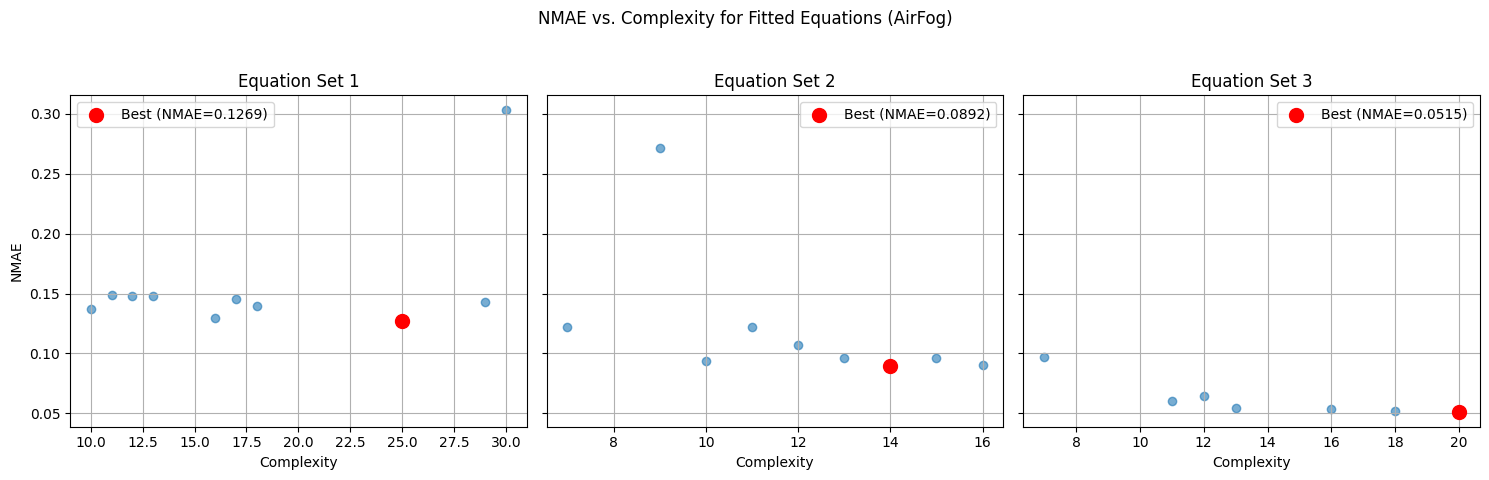

Experiment 2 finished.
Running experiment 3...


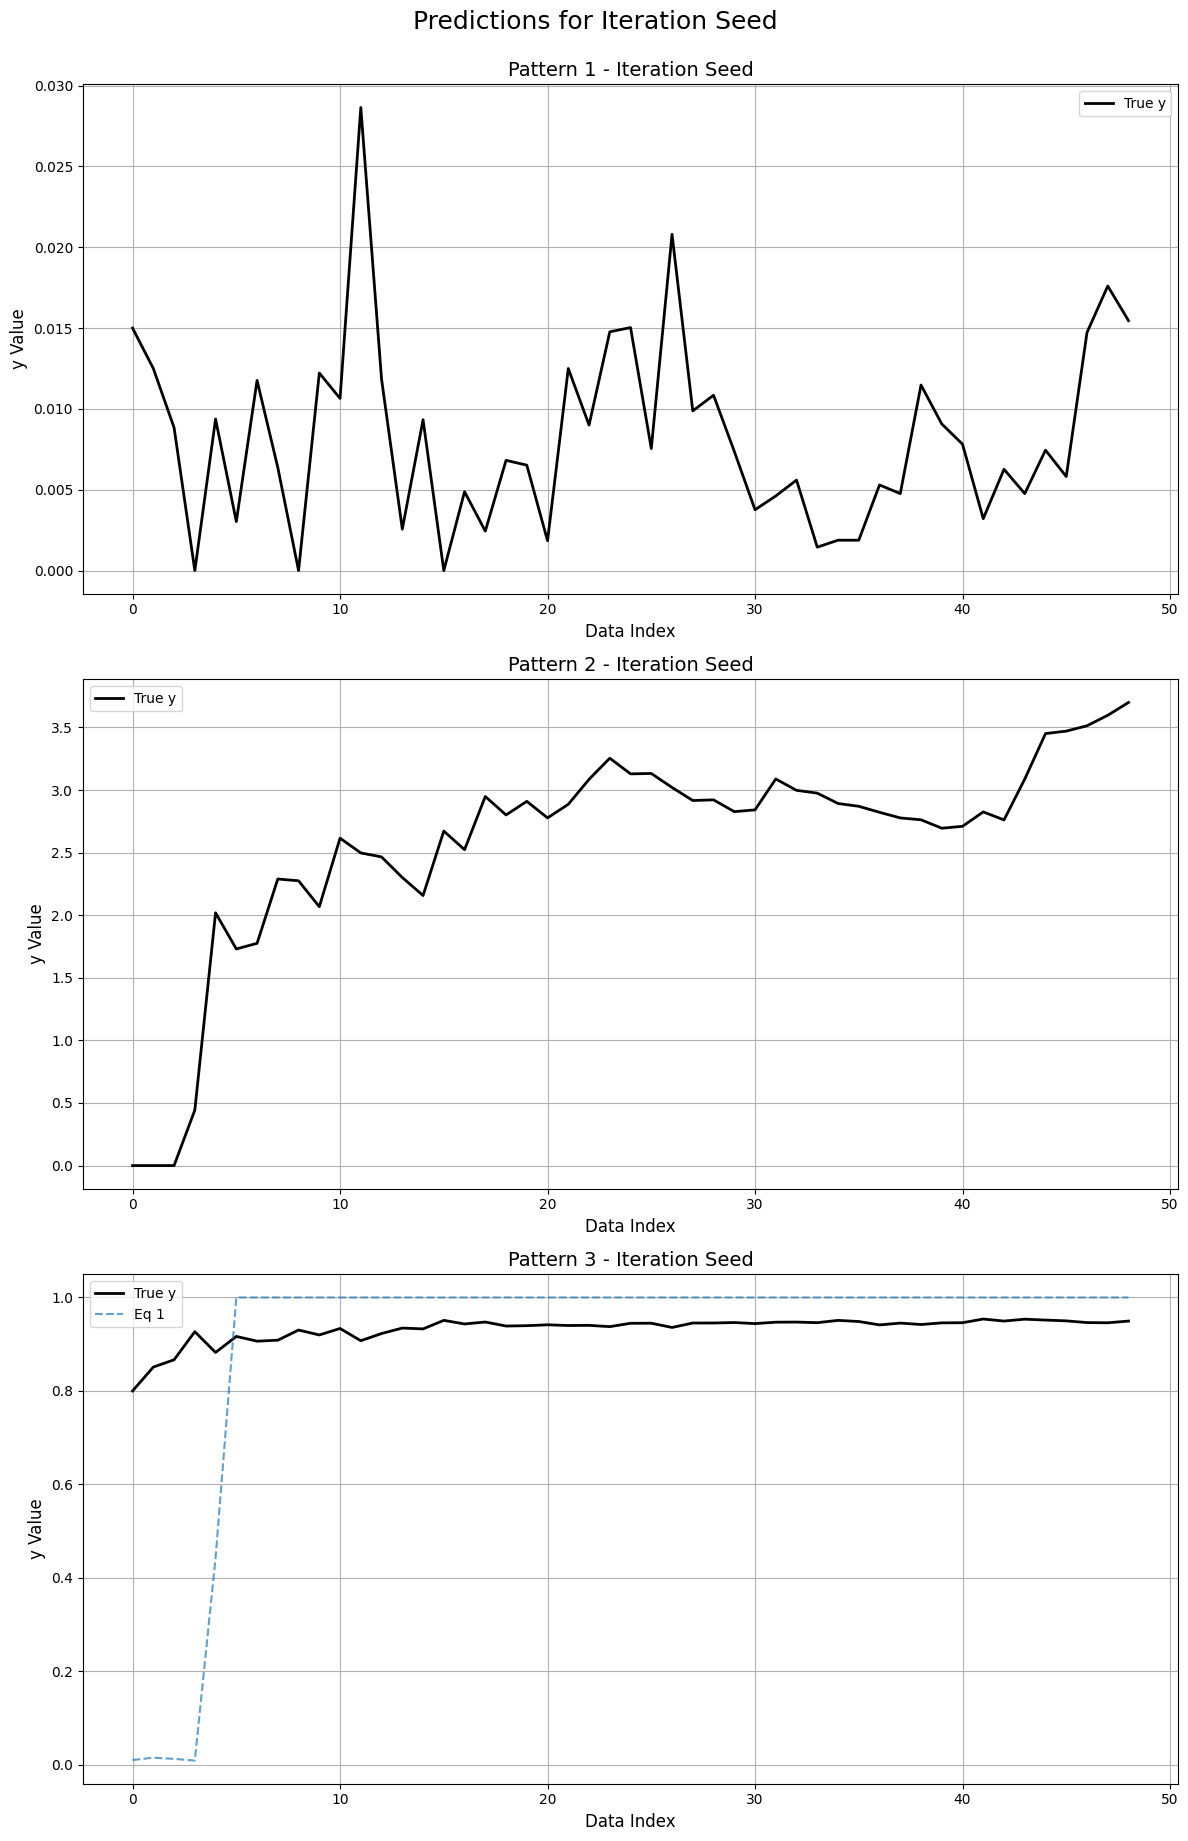

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1: 

The dataset for Pattern 1 shows a relationship between the average compute load and multiple factors such as task success ratio, vehicle density, and junction vehicle counts. The data suggests that the compute load might be influenced by a combination of polynomial terms and possibly logarithmic terms due to the complex oscillating behavior.

One potential expression could involve the polynomial terms for the task success ratio and vehicle density. The junction vehicle counts may contribute linearly due to traffic congestion effects.

Pattern 2: 

The dataset for Pattern 2 indicates a correlation between the average V2U rate and factors like vehicle density, UAV density, and compute load. Given the spatial constraints and communication range of UAVs, a polynomial or exponential form could be appropriate. The compute load might influence V2U rate through a polynomial relationship, considering the load

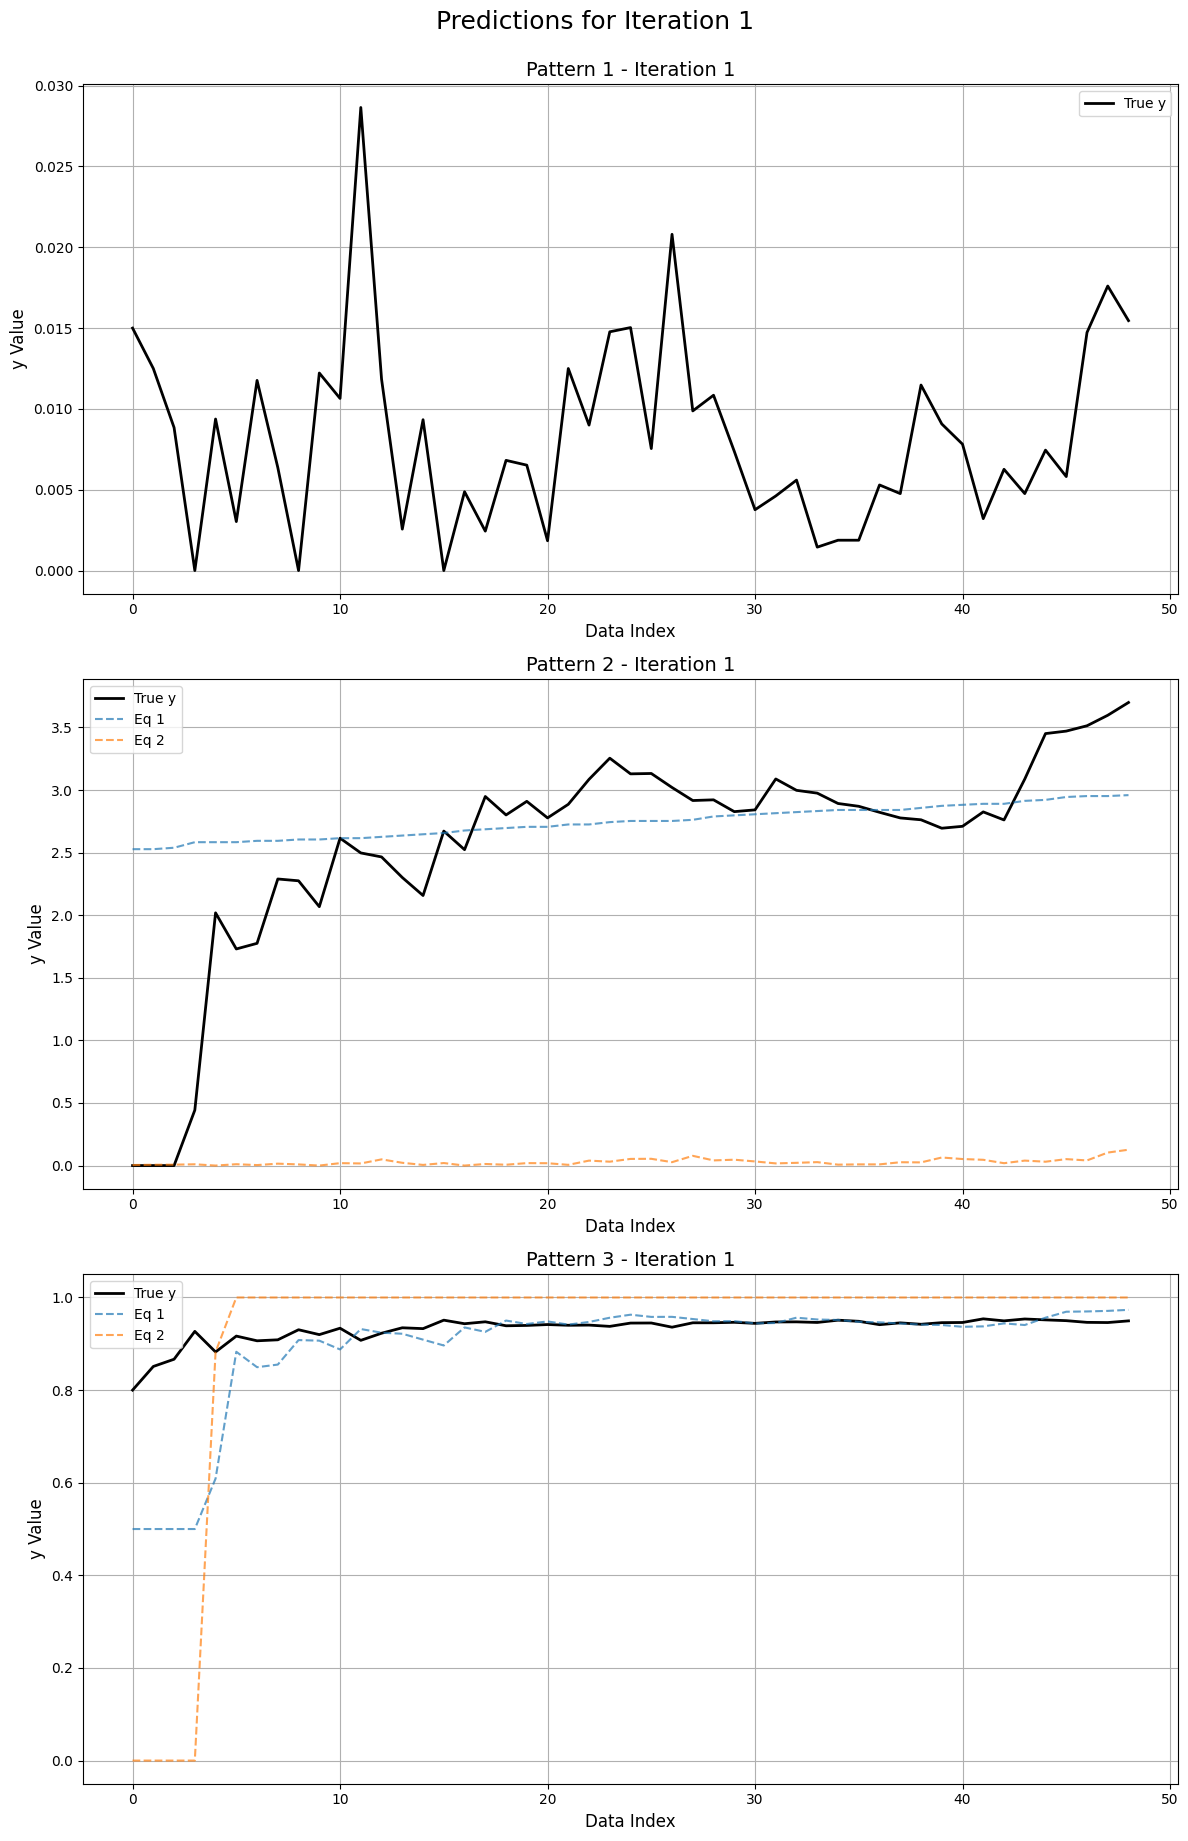

Iteration:1
SciPy feedback used for this iteration:
[[], [{'equation': 'log(x1+c[0])', 'complexity': 4, 'nmae': np.float64(0.12154046115948837), 'fitted_params': [12.091662278622696]}, {'equation': 'x1*x3', 'complexity': 3, 'nmae': np.float64(0.6891827312271223), 'fitted_params': []}], [{'equation': 'min(1,max(0,x1+x3))', 'complexity': 3, 'nmae': np.float64(0.8589151355324953), 'fitted_params': []}, {'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}, {'equation': 'min(1,max(0,x2/(x3+c[0])))', 'complexity': 5, 'nmae': np.float64(0.8067801821887782), 'fitted_params': [0.24413878750698498]}]]
LLM thoughts:
Pattern 1 Analysis:
- The task success ratio, vehicle density, and UAV density might have non-linear interactions with average compute load.
- Logarithmic and polynomial terms could capture non-linear relationships.
- Moving averages could smooth oscillations.

Pattern 2 Analysis:
- The V2U rate is likely influenced by vehicle de

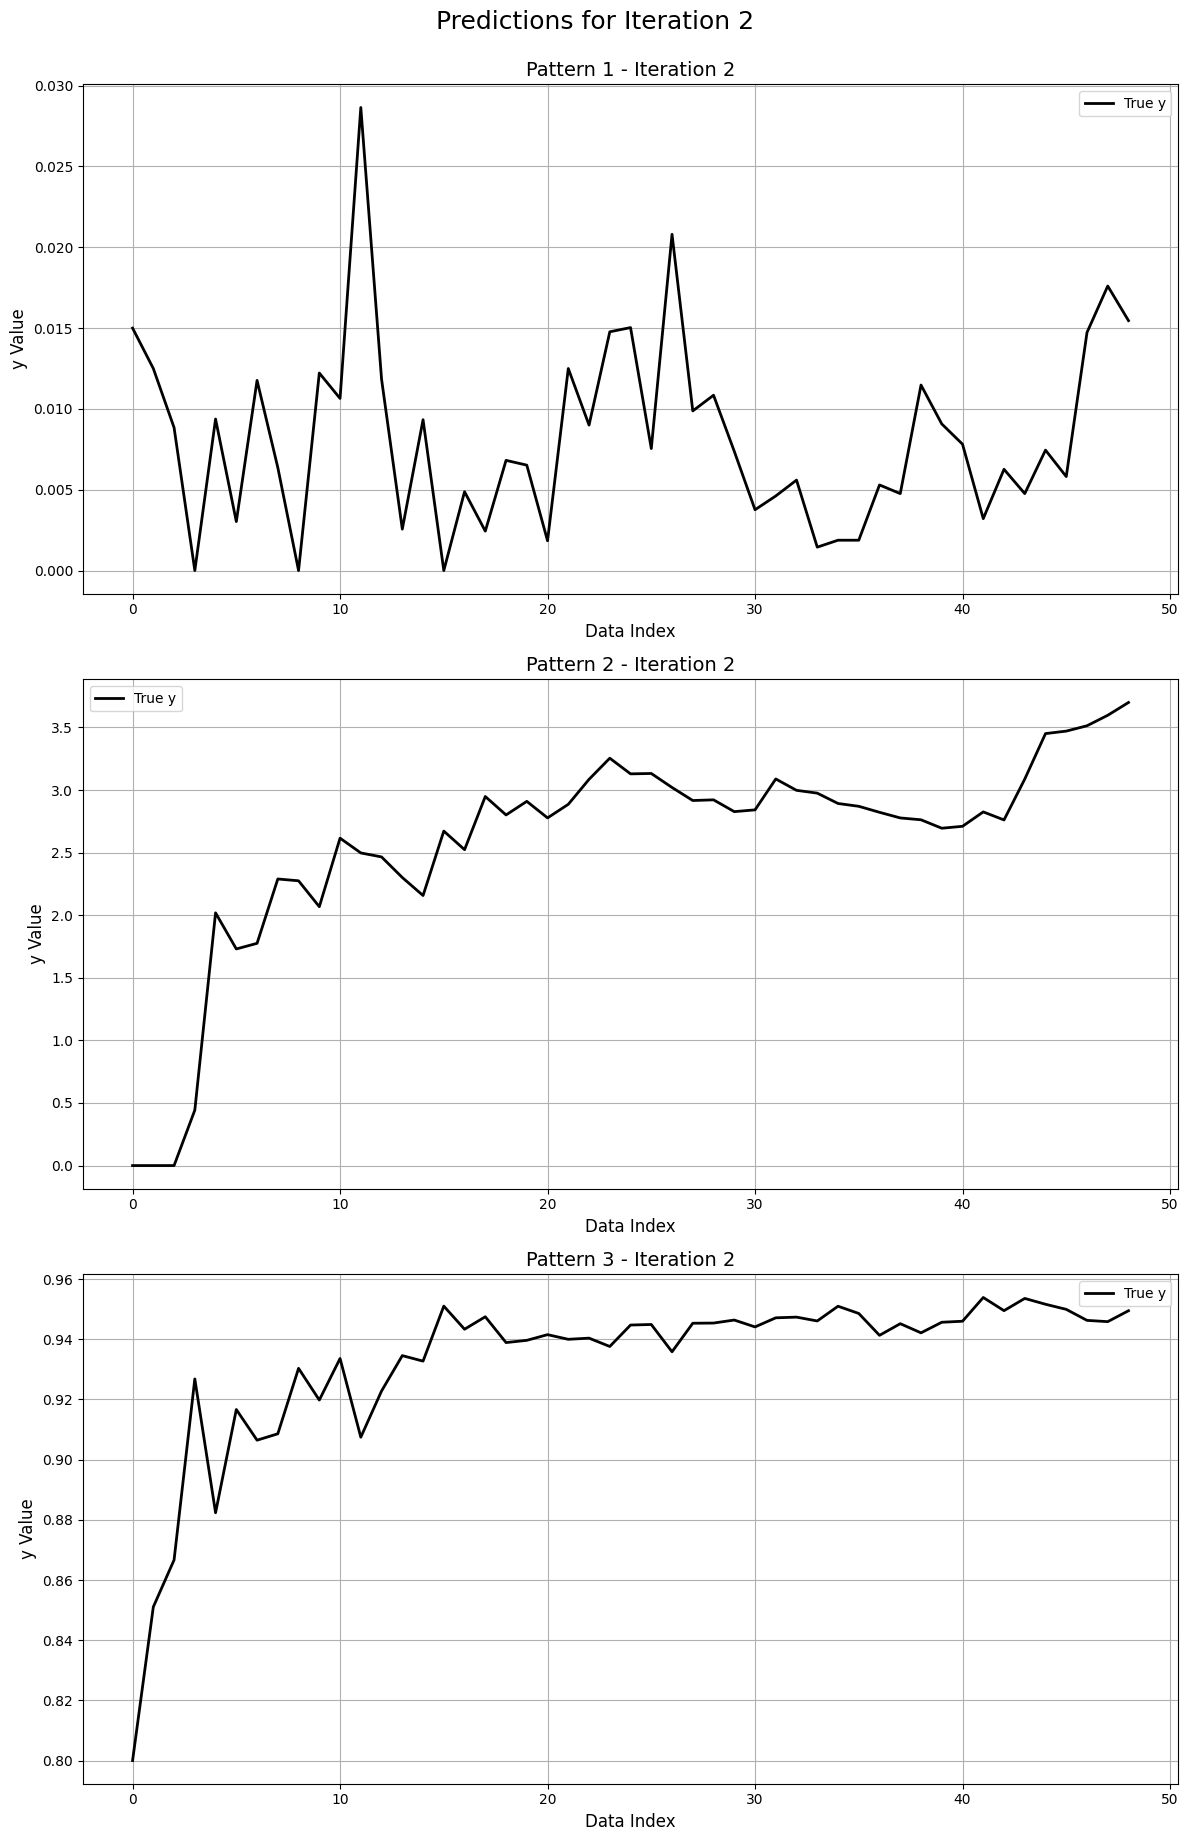

Iteration:2
SciPy feedback used for this iteration:
[[], [{'equation': 'log(x1+c[0])', 'complexity': 4, 'nmae': np.float64(0.12154046115948837), 'fitted_params': [12.091662278622696]}, {'equation': 'x1*x3', 'complexity': 3, 'nmae': np.float64(0.6891827312271223), 'fitted_params': []}], [{'equation': 'min(1,max(0,x1+x3))', 'complexity': 3, 'nmae': np.float64(0.8589151355324953), 'fitted_params': []}, {'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}, {'equation': 'min(1,max(0,x2/(x3+c[0])))', 'complexity': 5, 'nmae': np.float64(0.8067801821887782), 'fitted_params': [0.24413878750698498]}]]
LLM thoughts:
Analyzing the dataset, we need to suggest new equations for each pattern while minimizing complexity and loss. The existing Pareto front equations give us insights into the types of structures that have been effective, but we need to avoid redundancy by suggesting diverse alternatives.

For Pattern 1, the dependent variable is th

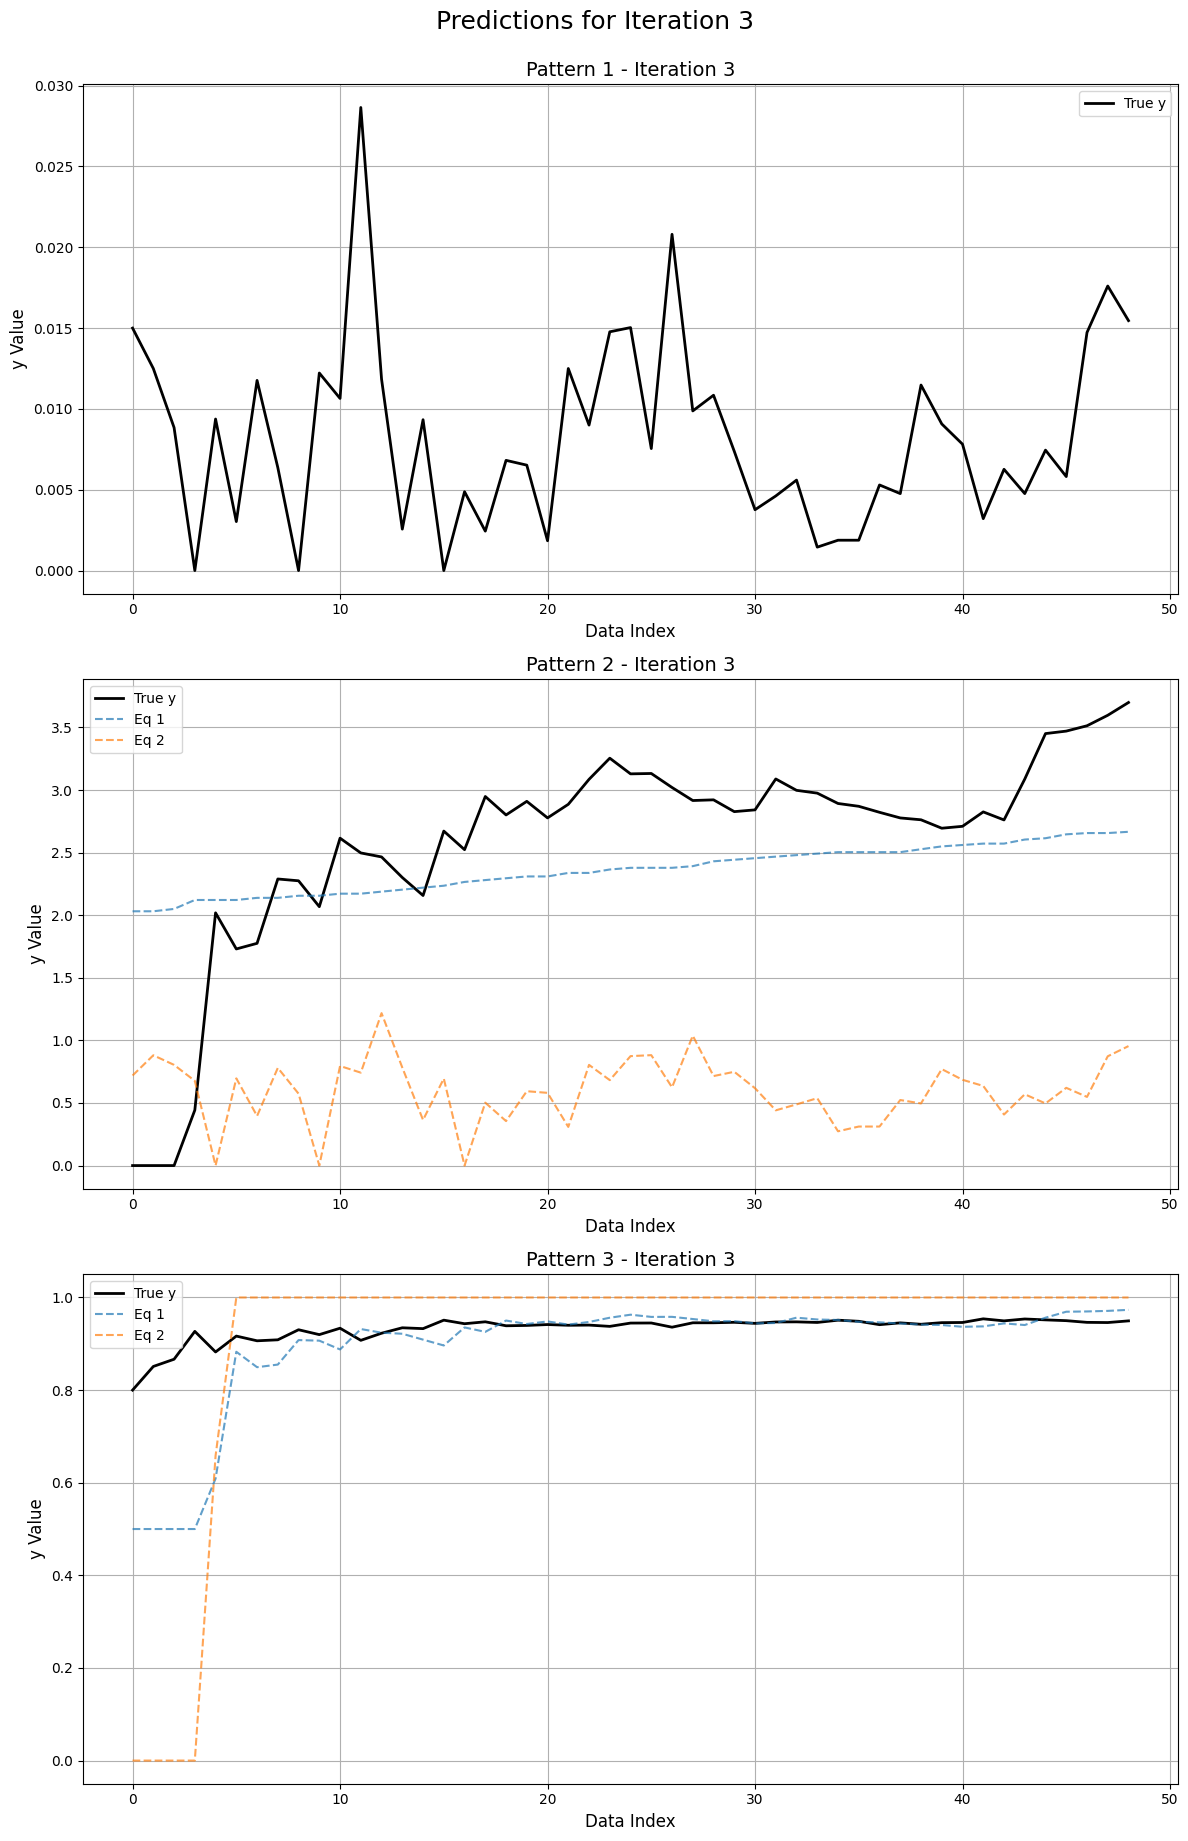

Iteration:3
SciPy feedback used for this iteration:
[[], [{'equation': 'log(x1+c[0])', 'complexity': 4, 'nmae': np.float64(0.12154046115948837), 'fitted_params': [12.091662278622696]}, {'equation': 'x1*x3', 'complexity': 3, 'nmae': np.float64(0.6891827312271223), 'fitted_params': []}, {'equation': 'log(x1+x2)', 'complexity': 4, 'nmae': np.float64(0.1554497691010926), 'fitted_params': []}, {'equation': 'x2*sqrt(x3)', 'complexity': 4, 'nmae': np.float64(0.5635452394154142), 'fitted_params': []}], [{'equation': 'min(1,max(0,x1+x3))', 'complexity': 3, 'nmae': np.float64(0.8589151355324953), 'fitted_params': []}, {'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}, {'equation': 'min(1,max(0,x2/(x3+c[0])))', 'complexity': 5, 'nmae': np.float64(0.8067801821887782), 'fitted_params': [0.24413878750698498]}, {'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}, {'equation': 'min(1,max

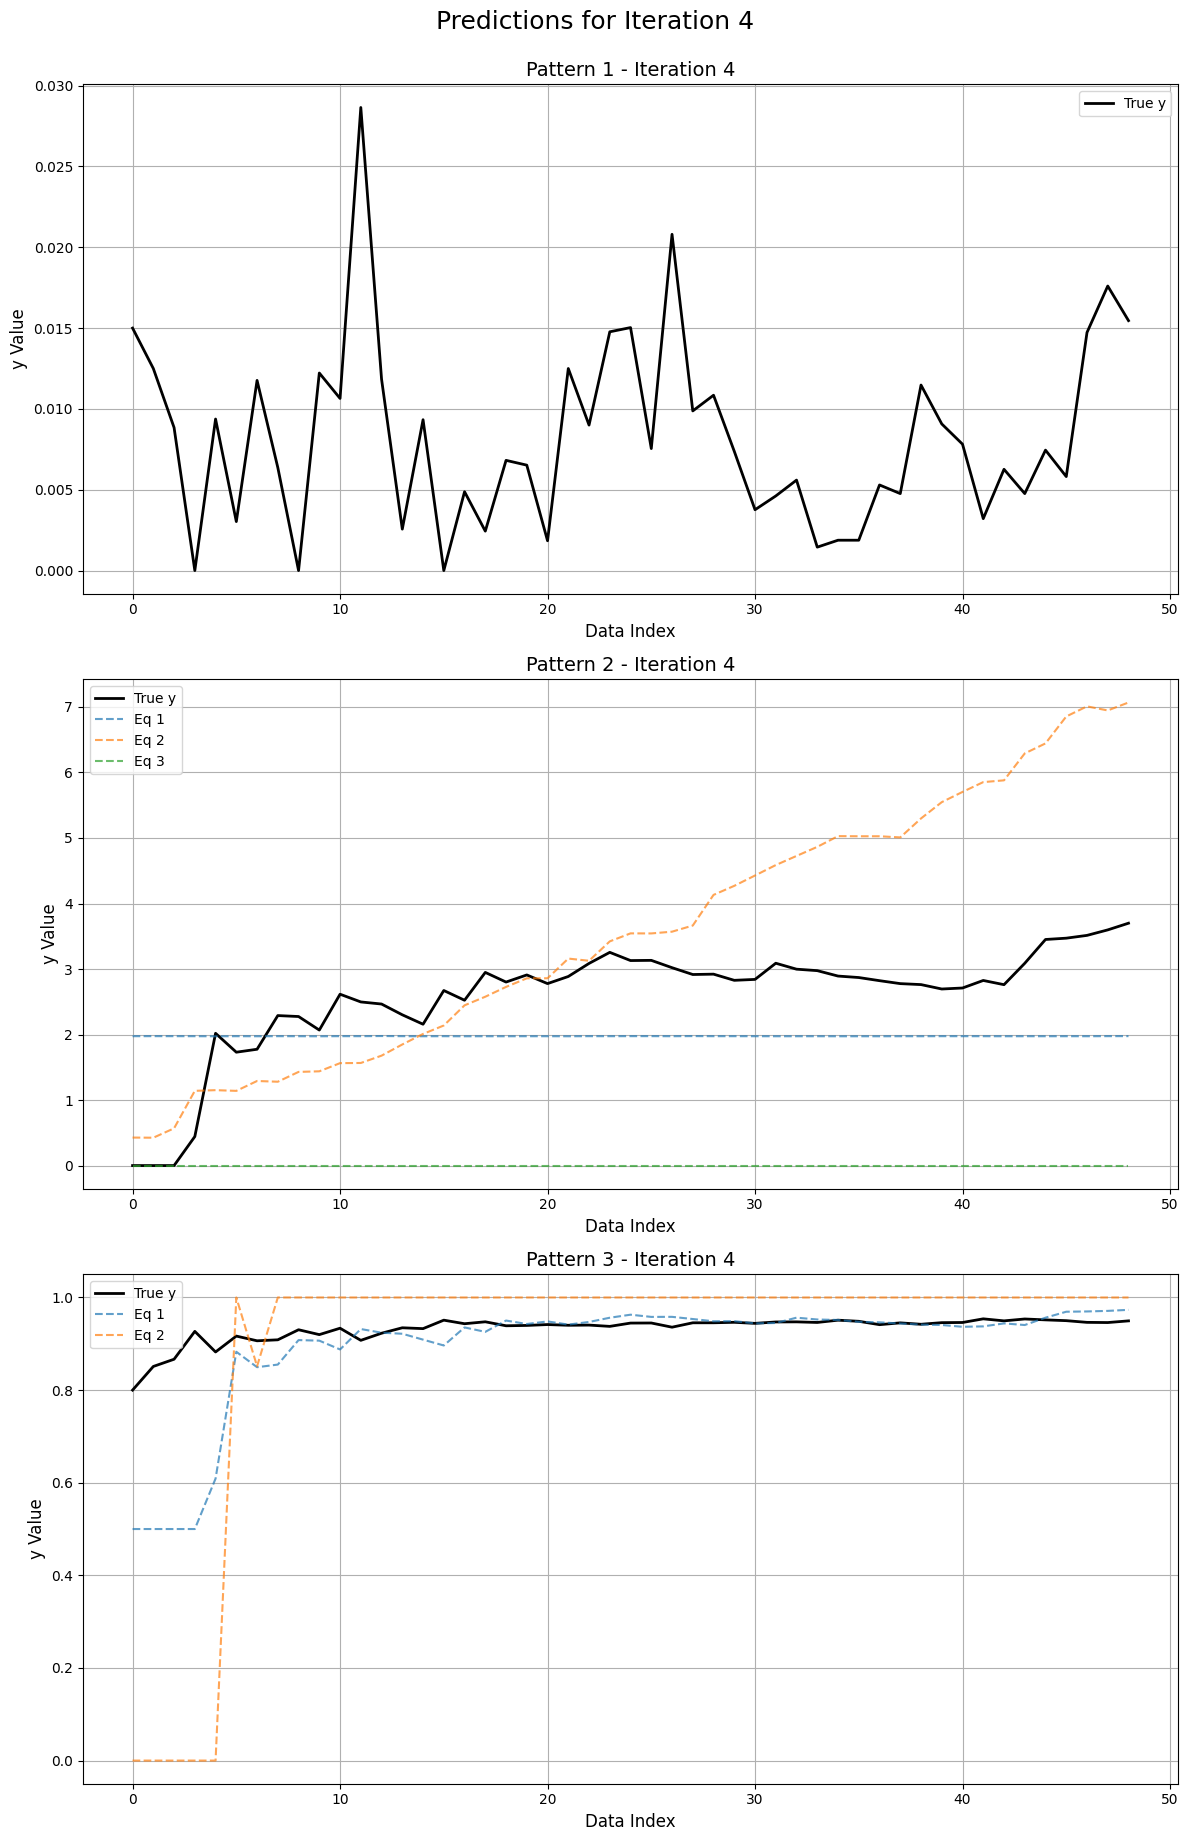

Iteration:4
SciPy feedback used for this iteration:
[[], [{'equation': 'x1*x3', 'complexity': 3, 'nmae': np.float64(0.6891827312271223), 'fitted_params': []}, {'equation': 'x1*exp(-x3)', 'complexity': 6, 'nmae': np.float64(0.3647359674802897), 'fitted_params': []}, {'equation': 'log(x1+x2)', 'complexity': 4, 'nmae': np.float64(0.1554497691010926), 'fitted_params': []}, {'equation': 'log(x1+c[0])', 'complexity': 4, 'nmae': np.float64(0.12154046115948837), 'fitted_params': [12.091662278622696]}], [{'equation': 'min(1,max(0,log(x1)+x2))', 'complexity': 4, 'nmae': np.float64(0.9186837301238397), 'fitted_params': []}, {'equation': 'min(1,max(0,x1+x2))', 'complexity': 3, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}, {'equation': 'min(1,max(0,x2/(x3+c[0])))', 'complexity': 5, 'nmae': np.float64(0.8067801821887782), 'fitted_params': [0.24413878750698498]}, {'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}]]
LLM thoughts

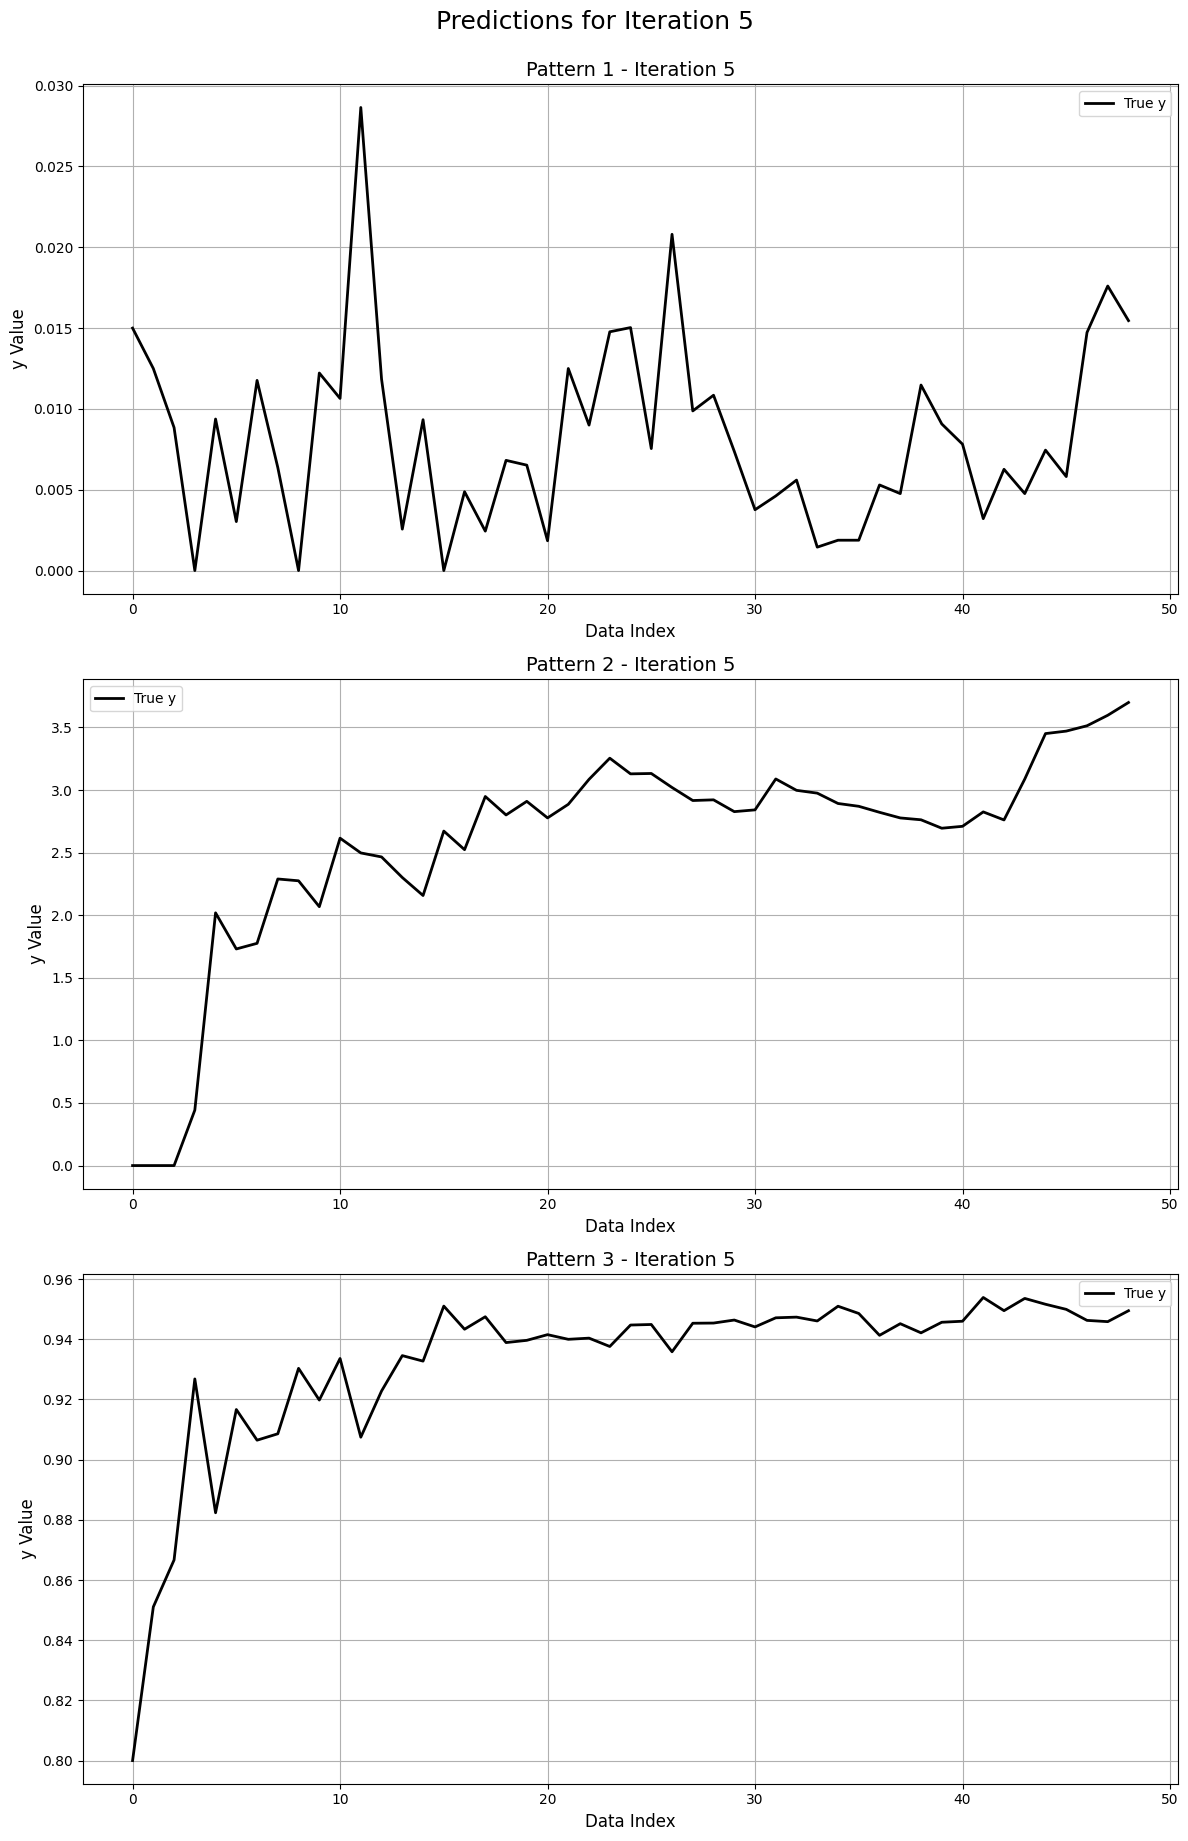

Iteration:5
SciPy feedback used for this iteration:
[[], [{'equation': 'x1*x3', 'complexity': 3, 'nmae': np.float64(0.6891827312271223), 'fitted_params': []}, {'equation': 'x1*exp(-x3)', 'complexity': 6, 'nmae': np.float64(0.3647359674802897), 'fitted_params': []}, {'equation': 'log(x1+x2)', 'complexity': 4, 'nmae': np.float64(0.1554497691010926), 'fitted_params': []}, {'equation': 'log(x1+c[0])', 'complexity': 4, 'nmae': np.float64(0.12154046115948837), 'fitted_params': [12.091662278622696]}], [{'equation': 'min(1,max(0,log(x1)+x2))', 'complexity': 4, 'nmae': np.float64(0.9186837301238397), 'fitted_params': []}, {'equation': 'min(1,max(0,x1+x2))', 'complexity': 3, 'nmae': np.float64(0.8364948597950002), 'fitted_params': []}, {'equation': 'min(1,max(0,x2/(x3+c[0])))', 'complexity': 5, 'nmae': np.float64(0.8067801821887782), 'fitted_params': [0.24413878750698498]}, {'equation': '1/(1+exp(-x1))', 'complexity': 8, 'nmae': np.float64(0.3153192998190748), 'fitted_params': []}]]
LLM thoughts

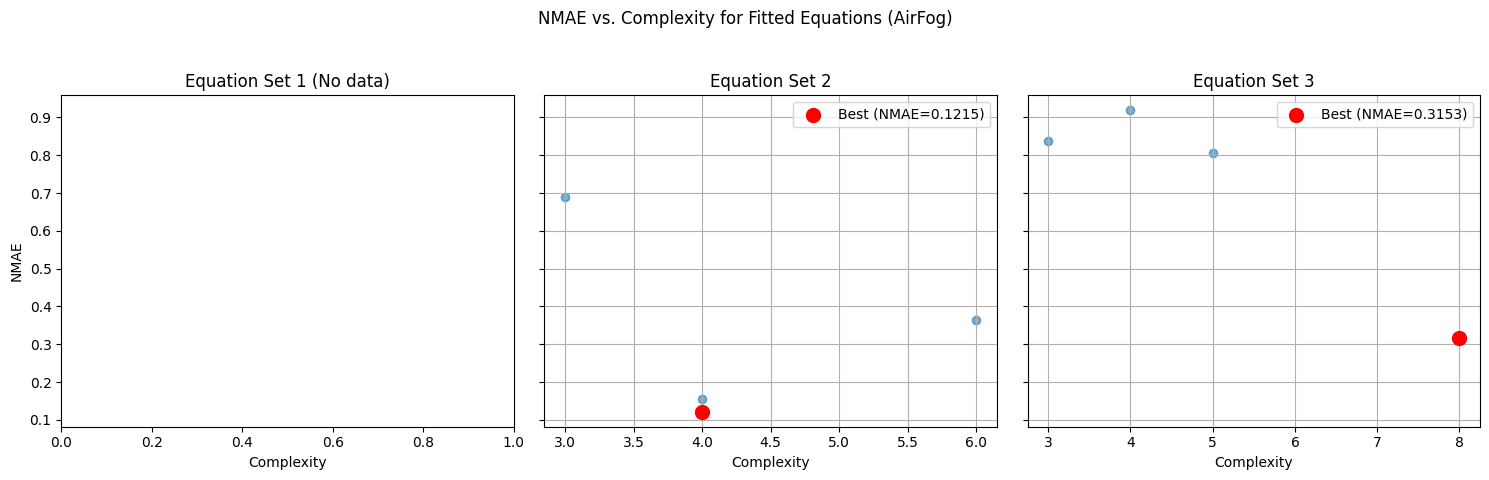

Experiment 3 finished.


In [6]:
import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "results/train"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")

    with open(f"{directory_path}/run{i+1}.json", 'w') as json_file:
        json.dump(results, json_file, indent=2)

In [1]:
from helper import format_and_parse_expression_matrix, format_expressions

llm_array_output = '\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1^2 + c_1 \\cdot \\log(x_2) + c_2 \\cdot (x_4 + x_5 + x_6)", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2^3 + c_2 \\cdot \\sqrt{x_3}", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_4^2"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1 \\cdot x_2 + c_1 \\cdot x_3", \\\\\n"c_0 \\cdot x_1^2 + c_1 \\cdot x_2^2 + c_2 \\cdot x_3", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot \\log(x_3)"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"1 / (1 + \\exp(-(c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3)))", \\\\\n"\\min(1, \\max(0, c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3))", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3"\n\\end{array}\n\\right] \\]'
llm_bmatrix_output = """\\[
\\begin{bmatrix}
\\text{Pattern 1:} & \\left[ \\text{"x1^2 + x2*x3"}, \\, \\text{"\\log(x1 + x2) + \\sqrt{x3}"}, \\, \\text{"x1*x2 + \\frac{x3}{x1}"} \\right] \\\\
\\text{Pattern 2:} & \\left[ \\text{"x1 + x3"}, \\, \\text{"\\exp(x1) - x2"}, \\, \\text{"x1*x3 - \\log(x2)"} \\right] \\\\
\\text{Pattern 3:} & \\left[ \\text{"\\frac{1}{1 + \\exp(-x1)}"}, \\, \\text{"\\min(1, \\max(0, x1 + x2 - x3))"}, \\, \\text{"\\frac{x1}{1 + x3}"} \\right]
\\end{bmatrix}
\\]"""
llm_align_output = '\\[ \n\\begin{align*}\n\\text{Pattern 1:} \\\\\n& y1 = c_0 \\cdot x1^2 + c_1 \\cdot movavg(x2, 3) + c_2 \\cdot log(x4 + x5), \\\\\n& y2 = c_0 \\cdot x1 \\cdot x2 + c_1 \\cdot x3^2 + c_2 \\cdot sqrt(x6), \\\\\n& y3 = c_0 \\cdot log(x1 + x2) + c_1 \\cdot movavg(x5, 2) + c_2 \\cdot x4 \\cdot x6; \\\\\n\\text{Pattern 2:} \\\\\n& y1 = c_0 \\cdot x1 \\cdot x3 + c_1 \\cdot sqrt(x2), \\\\\n& y2 = c_0 \\cdot x1^2 + c_1 \\cdot x3^2 + c_2 \\cdot movavg(x1, 4), \\\\\n& y3 = c_0 \\cdot log(x1) + c_1 \\cdot x2 \\cdot x3; \\\\\n\\text{Pattern 3:} \\\\\n& y1 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot x2 + c_2 \\cdot x3))}, \\\\\n& y2 = \\min(1, \\max(0, c_0 \\cdot x1^2 + c_1 \\cdot x2 + c_2 \\cdot \\log(x3))), \\\\\n& y3 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot \\sqrt{x2) + c_2 \\cdot x3))}.\n\\end{align*}\n\\]'

# Parse the LLM output
parsed_matrix = format_and_parse_expression_matrix(llm_align_output)
# Print the parsed matrix
for row in parsed_matrix:
    print("Parsed Row:")
    print(row)
    print("Formatted Row:")
    print(format_expressions(row))
    print("\n")


Parsed Row:
['c[0] \\cdot x1^2 + c[1] \\cdot movavg(x2, 3) + c[2] \\cdot log(x4 + x5)', 'c[0] \\cdot x1 \\cdot x2 + c[1] \\cdot x3^2 + c[2] \\cdot sqrt(x6)', 'c[0] \\cdot log(x1 + x2) + c[1] \\cdot movavg(x5, 2) + c[2] \\cdot x4 \\cdot x6']
Formatted Row:
['c[0]*x1**2+c[1]*movavg(2, 3)+c[2]*log(x4+x5)', 'c[0]*x1*x2+c[1]*x3**2+c[2]*sqrt(x6)', 'c[0]*log(x1+x2)+c[1]*movavg(5, 2)+c[2]*x4*x6']


Parsed Row:
['c[0] \\cdot x1 \\cdot x3 + c[1] \\cdot sqrt(x2)', 'c[0] \\cdot x1^2 + c[1] \\cdot x3^2 + c[2] \\cdot movavg(x1, 4)', 'c[0] \\cdot log(x1) + c[1] \\cdot x2 \\cdot x3']
Formatted Row:
['c[0]*x1*x3+c[1]*sqrt(x2)', 'c[0]*x1**2+c[1]*x3**2+c[2]*movavg(1, 4)', 'c[0]*log(x1)+c[1]*x2*x3']


Parsed Row:
['(1) / (1 + \\exp(-(c[0] \\cdot x1 + c[1] \\cdot x2 + c[2] \\cdot x3)))', '\\min(1, \\max(0, c[0] \\cdot x1^2 + c[1] \\cdot x2 + c[2] \\cdot \\log(x3)))', '(1) / (1 + \\exp(-(c[0] \\cdot x1 + c[1] \\cdot \\sqrt{x2) + c[2] \\cdot x3))).']
Formatted Row:
['(1)/(1+exp(-(c[0]*x1+c[1]*x2+c[2]*x3)))',